In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [2]:
df= pd.read_csv(r'C:\Projects\bda_exam\(아이엠뱅크) 2025 교육용 데이터\(아이엠뱅크) 2025 교육용 데이터.csv', encoding='cp949')
#df_c = pd.read_csv(r'C:\Projects\bda_exam\(아이엠뱅크) 2025 교육용 데이터\iM뱅크_금리현황_2022-2024(post).csv')
df_b = pd.read_csv(r'C:\Projects\bda_exam\(아이엠뱅크) 2025 교육용 데이터\iM뱅크_금리현황_2022-2024.csv')
fee_df = pd.read_csv(r'C:\Projects\bda_exam\(아이엠뱅크) 2025 교육용 데이터\추정비이자수익률.csv')

In [3]:
# 한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [4]:
count_mapping = {
    "0건": 0,
    "1건": 1,
    "2건": 2,
    "2건초과 5건이하": 3.5,
    "5건초과 10건이하": 7.5,
    "10건초과 20건이하": 15,
    "20건초과 30건이하": 25,
    "30건초과 40건이하": 35,
    "40건초과 50건이하": 45,
    "50건 초과": 55,
}

channel_count_cols = [
    "인터넷뱅킹거래건수",
    "스마트뱅킹거래건수",
    "폰뱅킹거래건수",
    "자동이체거래건수",
    "창구거래건수",
    "ATM거래건수",
    "외환_수출실적거래건수",
    "외환_수입실적거래건수",
]

for col in channel_count_cols:
    if col in df.columns:
        df[col] = df[col].map(count_mapping)

account_mapping = {
    "0개": 0,
    "1개": 1,
    "2개": 2,
    "2개초과 5개이하": 4,
    "5개초과 10개이하": 8,
    "10개초과 20개이하": 15.5,
    "20개초과 30개이하": 25.5,
    "30개초과 40개이하": 35.5,
    "40개초과 50개이하": 45.5,
    "50개 초과": 55,
}

account_count_cols = [
    "요구불예금좌수",
    "거치식예금좌수",
    "적립식예금좌수",
    "수익증권좌수",
    "신탁좌수",
    "퇴직연금좌수",
    "여신_운전자금대출좌수",
    "여신_시설자금대출좌수",
    "신용카드개수",
]

for col in account_count_cols:
    if col in df.columns:
        df[col] = df[col].map(account_mapping)

In [5]:
# 1. 자산성 지표 (Asset)
# 근거: 법인의 현금 동원력과 재무 안정성을 나타냄. 
# 단순히 합치지 않고 '요구불(유동성)'과 '장기저축성'을 묶어 법인의 자금 성격을 파악.
deposit_bal_cols = ["요구불예금잔액", "거치식예금잔액", "적립식예금잔액"]  
product_bal_cols = ["수익증권잔액", "신탁잔액", "퇴직연금잔액"]  
deposit_cnt_cols = ["요구불예금좌수", "거치식예금좌수", "적립식예금좌수"]  
product_cnt_cols = ["수익증권좌수", "신탁좌수", "퇴직연금좌수"]  
flow_cols = ["요구불입금금액", "요구불출금금액"]

# 2. 여신(대출) 지표 (Debt)
# 근거: 운전자금(운영비)과 시설자금(투자)을 구분. 
# 시설자금 비중이 높으면 공장이나 설비를 가진 '제조/생산형 법인'일 확률이 매우 높음.
loan_bal_cols = ["여신_운전자금대출잔액", "여신_시설자금대출잔액"]  
loan_cnt_cols = ["여신_운전자금대출좌수", "여신_시설자금대출좌수"]
 
# 3. 영업 거래 지표 (Transaction)
# 근거: 창구 거래가 많으면 '전통적/오프라인', 스마트뱅킹이 많으면 '젊은/온라인' 기업.
# 자동이체와 카드 사용액은 기업의 활동성을 대변함.

rjfo_total = ['인터넷뱅킹거래금액', '폰뱅킹거래금액' , '스마트뱅킹거래금액', '창구거래금액', 'ATM거래금액']
rjfo_digital = ['인터넷뱅킹거래금액', '폰뱅킹거래금액' , '스마트뱅킹거래금액']
rjfo_offline = ['창구거래금액', 'ATM거래금액']

rjfo_card_total = ['신용카드사용금액', '체크카드사용금액']

channel_cnt_cols = [  
   "창구거래건수",  
   "인터넷뱅킹거래건수",  
   "스마트뱅킹거래건수",  
   "폰뱅킹거래건수",  
   "ATM거래건수",  
]

# 4. 대외 무역 지표 (Global)
# 근거: 수출입 실적은 공단 지역(달성군, 북구 등) 보간의 결정적 근거.
dhlghks = ['외환_수출실적금액', '외환_수입실적금액']



In [6]:
# 피처 생성
df['총예금잔액'] = df[deposit_bal_cols].sum(axis=1)
df['자산관리잔액'] = df[product_bal_cols].sum(axis=1)
df['총대출잔액'] = df[loan_bal_cols].sum(axis=1)
df['총예금좌수'] = df[deposit_cnt_cols].sum(axis=1)
df['총대출좌수'] = df[loan_cnt_cols].sum(axis=1)
df['자산관리좌수']= df[product_cnt_cols].sum(axis=1)
df['총요구불입출금'] = df[flow_cols].sum(axis=1)

df['전체거래액'] = df[rjfo_total].sum(axis=1)
df['총디지털거래액'] = df[rjfo_digital].sum(axis=1)
df['총오프라인거래액'] = df[rjfo_offline].sum(axis=1)
df['총카드소비'] = df[rjfo_card_total].sum(axis=1)

df['총외환실적'] = df[dhlghks].sum(axis=1)


In [9]:
# 2. 필요한 컬럼만 선택 (기준년월, 평균대출금리, 평균예금금리, 예대마진)
# 만약 엑셀의 열 이름이 정확히 일치하지 않는다면 엑셀에 적힌 실제 이름으로 수정해야 합니다.
cols_to_use = ['기준년월', '평균대출금리(%)', '평균예금금리(%)', '예대마진(%)']
df_b_subset = df_b[cols_to_use]

# 3. 기존 데이터(a)와 병합 (Left Join)
# df_a는 이미 파이썬에서 작업 중인 데이터프레임이라고 가정합니다.
df2 = pd.merge(df, df_b_subset, on='기준년월', how='left')


In [10]:
fee_df.columns = fee_df.columns.str.strip() # 컬럼명 공백 제거

# 2. 에러 방지: df2에 이미 수수료율 관련 컬럼이 있다면 미리 삭제
target_fee_cols = ['신탁보수율(trust)', '카드수수료율(card)', '수익증권/연금(fund)', '외환/기타(fx)', '채널건당(channel)', '연도(year)']
df2 = df2.drop(columns=[c for c in target_fee_cols if c in df2.columns])

# 3. 기준년월 처리 및 연도 키 생성
# '기준년월'이 202201(숫자) 형태라면 // 100을, 문자열이라면 앞 4글자를 사용합니다.
try:
    df2['연도_join'] = (df2['기준년월'].astype(int) // 100)
except:
    df2['연도_join'] = df2['기준년월'].astype(str).str[:4].astype(int)

# 4. 데이터 병합 (how='left'로 원본 데이터 유지)
df2 = pd.merge(df2, fee_df, left_on='연도_join', right_on='연도(year)', how='left')

# 5. 단위 환산 및 수익 계산
# df2의 금액 컬럼들: 백만원 단위
# 수수료율: 소수점 형태 (예: 0.004) -> 결과도 백만원 단위
# 채널건당: 300원 -> 백만원 단위로 변환 필요 (300 / 1,000,000)

# (1) 수익증권수익
df2['수익증권수익'] = df2['수익증권잔액'] * df2['수익증권/연금(fund)']

# (2) 신탁수익
df2['신탁수익'] = df2['신탁잔액'] * df2['신탁보수율(trust)']

# (3) 퇴직연금수익
# df2['퇴직연금수익'] = df2['퇴직연금잔액'] * df2['수익증권/연금(fund)']

# (4) 외환수익
df2['외환수익'] = (df2['외환_수출실적금액'] + df2['외환_수입실적금액']) * df2['외환/기타(fx)']

# (5) 카드수익a
df2['카드수익'] = (df2['신용카드사용금액'] + df2['체크카드사용금액']) * df2['카드수수료율(card)']

# 창구 수수료 및 이체 수수료는 현재 수익성에 큰 의미가 없음 -> 해당 비이자수익은 제외

# 6. 최종 추정 비이자수익 합산 (결과 단위: 백만원)
df2['추정_비이자수익'] = (
    df2['수익증권수익'].fillna(0) +
    df2['신탁수익'].fillna(0) +
    df2['외환수익'].fillna(0) +
    df2['카드수익'].fillna(0)
)

# 7. 임시 컬럼 정리
df2 = df2.drop(columns=['연도_join', '연도(year)'])

# 확인
print(df2[['기준년월', '추정_비이자수익']].head(10))

     기준년월  추정_비이자수익
0  202412  0.000000
1  202412  0.000000
2  202412  0.000293
3  202412  0.000000
4  202412  0.032034
5  202412  0.000000
6  202412  0.001227
7  202412  0.027720
8  202412  0.000548
9  202412  0.001510


In [11]:
# 4. 변수 추가+ 결과 확인
df2['총자산']= (df2['총예금잔액']+df2['총대출잔액'])
df2['예금이자']=df2['총예금잔액']*df2['평균예금금리(%)']*0.01 /12
df2['대출이자']=df2['총대출잔액']*df2['평균대출금리(%)']*0.01 /12
df2['예대마진']=df2['대출이자']-df2['예금이자']
df2['예대마진수익률(%)']=(df2['대출이자']-df2['예금이자'])/(df2['총자산'])*100
df2['예대마진수익률(%)']=df2['예대마진수익률(%)'].fillna(0)
df2['추정_비이자수익']
df2['이자+비이자수익']=df2['예대마진']+df2['추정_비이자수익']
df2['자산대비수익률']=df2['이자+비이자수익']/df2['총자산']*100
print(df2.head())

     기준년월 업종_대분류  업종_중분류 사업장_시도 사업장_시군구 법인_고객등급 전담고객여부  요구불예금잔액  거치식예금잔액  \
0  202412    건설업  종합 건설업  대구광역시      서구      일반      N     0.16      0.0   
1  202412    건설업  종합 건설업  대구광역시      서구      일반      N     0.03      0.0   
2  202412    건설업  종합 건설업  대전광역시      서구      우수      N     0.24      0.0   
3  202412    건설업  종합 건설업  대구광역시      서구      우수      Y   180.00      0.0   
4  202412    건설업  종합 건설업  대구광역시      서구      우수      Y    41.00      0.0   

   적립식예금잔액  ...  외환수익      카드수익  추정_비이자수익      총자산      예금이자      대출이자  \
0      0.0  ...   0.0  0.000000  0.000000    70.16  0.000035  0.023917   
1      0.0  ...   0.0  0.000000  0.000000     1.23  0.000006  0.000410   
2      0.0  ...   0.0  0.000293  0.000293   430.24  0.000052  0.146917   
3      0.0  ...   0.0  0.000000  0.000000  3580.00  0.039000  1.161667   
4      0.0  ...   0.0  0.001794  0.032034    41.00  0.008883  0.000000   

       예대마진  예대마진수익률(%)  이자+비이자수익   자산대비수익률  
0  0.023882    0.034039  0.023882  0.034039  
1  0.0

In [12]:
# 1. 세종특별자치시인 경우 시군구를 '세종시'로 자동 채우기
# (이미 시도가 세종시로 되어 있는 데이터들 중 시군구가 Null인 경우를 해결)
df2.loc[df2['사업장_시도'] == '세종특별자치시', '사업장_시군구'] = '세종시'

# 2. 나머지 모든 '사업장_시도'와 '사업장_시군구'의 Null값을 '미상'으로 일괄 변경
df2['사업장_시도'] = df2['사업장_시도'].fillna('미상')
df2['사업장_시군구'] = df2['사업장_시군구'].fillna('미상')

# 3. 결과 확인
print("=== [결측치 처리 후 지역 분포 확인] ===")
print(df2['사업장_시도'].value_counts().head(10))

# 4. 세종시 보정 결과 확인
sejong_check = df2[df2['사업장_시도'] == '세종특별자치시']['사업장_시군구'].unique()
print(f"\n세종시 내 시군구 리스트: {sejong_check}")

=== [결측치 처리 후 지역 분포 확인] ===
사업장_시도
대구광역시    153267
경상북도     116072
미상        16993
서울특별시     16477
부산광역시     16172
경상남도      10845
경기도        9734
울산광역시      3245
인천광역시      2953
대전광역시      1218
Name: count, dtype: int64

세종시 내 시군구 리스트: ['세종시']


In [13]:
# 딕셔너리 형태로 깔끔하게 변경
df2 = df2.rename(columns={
    '평균대출금리(%)': '월평균대출금리(%)',
    '평균예금금리(%)': '월평균예금금리(%)'
})

In [20]:
df2['자산대비수익률'] = df2['자산대비수익률'].fillna(0)

In [17]:
a = df2[df2['자산대비수익률'].isnull()].copy()


In [22]:
a['법인_고객등급'].value_counts()

법인_고객등급
일반     879
최우수    361
우수     140
Name: count, dtype: int64

In [284]:
cc= df2[(df2['총예금잔액']==0) & (df2['총대출잔액']==0)]

In [286]:
cc

,기준년월,업종_대분류,업종_중분류,사업장_시도,사업장_시군구,법인_고객등급,전담고객여부,요구불예금잔액,거치식예금잔액,적립식예금잔액,수익증권잔액,신탁잔액,퇴직연금잔액,여신한도금액,여신_운전자금대출잔액,여신_시설자금대출잔액,외환_수출실적금액,외환_수입실적금액,신용카드사용금액,체크카드사용금액,창구거래금액,인터넷뱅킹거래금액,스마트뱅킹거래금액,폰뱅킹거래금액,ATM거래금액,자동이체금액,요구불입금금액,요구불출금금액,요구불예금좌수,거치식예금좌수,적립식예금좌수,수익증권좌수,신탁좌수,퇴직연금좌수,여신_운전자금대출좌수,여신_시설자금대출좌수,신용카드개수,외환_수출실적거래건수,외환_수입실적거래건수,창구거래건수,인터넷뱅킹거래건수,스마트뱅킹거래건수,폰뱅킹거래건수,ATM거래건수,자동이체거래건수,총예금잔액,자산관리잔액,총대출잔액,총예금좌수,총대출좌수,자산관리좌수,총요구불입출금,전체거래액,총디지털거래액,총오프라인거래액,총카드소비,총외환실적,예대마진,고객유형,평균대출금리(%),평균예금금리(%),예대마진(%),총자산,예금이자,대출이자,예대마진n,예대마진수익률n(%),신탁보수율(trust),카드수수료율(card),수익증권/연금(fund),외환/기타(fx),채널건당(channel),수익증권수익,신탁수익,퇴직연금수익,외환수익,카드수익,추정_비이자수익,이자수익비율,비이자수익비율,종합수익성지표
37,202412,제조업,고무 및 플라스틱제품 제조업,대구광역시,서구,일반,N,0.0,0.0,0.0,0.0,0.0,0.0,300.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,4.0,0.0,0.0,0.0,0.0,0.0,15.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,15.5,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,비용 유발형,0.41,0.26,0.15,0.0,0.0,0.0,0.0,0.0,0.003021,0.011333,0.004,0.001,300,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000
434,202412,제조업,목재 및 나무제품 제조업; 가구 제외,인천광역시,서구,최우수,Y,0.0,0.0,0.0,0.0,0.0,0.0,15000.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,10000.0,0.00,0.0,10000.00,0.00,20000.00,20000.0,1.0,0.0,0.0,0.0,1.0,0.0,15.5,0.0,0.0,0.0,0.0,1.0,15.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,15.5,1.0,40000.00,20010.00,10000.00,10010.00,0.0,0.0,0.0,비용 유발형,0.41,0.26,0.15,0.0,0.0,0.0,0.0,0.0,0.003021,0.011333,0.004,0.001,300,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000
439,202412,금융 및 보험업,금융업,대전광역시,서구,최우수,Y,0.0,0.0,0.0,0.0,0.0,0.0,50000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36000.0,0.00,0.0,100000.00,0.01,86000.00,86000.0,1.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,55.0,0.0,0.0,3.5,2.0,0.0,0.0,0.0,1.0,8.0,0.0,172000.00,136000.00,36000.00,100000.00,0.0,0.0,0.0,비용 유발형,0.41,0.26,0.15,0.0,0.0,0.0,0.0,0.0,0.003021,0.011333,0.004,0.001,300,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000
865,202412,"협회 및 단체, 수리 및 기타 개인 서비스업",협회 및 단체,대구광역시,동구,일반,N,0.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0,0.0,2.8,0.0,0.0,0.0,0.75,2.9,1.90,2.60,7.90,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,3.5,7.5,3.5,7.5,0.0,0.0,0.0,1.0,0.0,0.0,11.90,5.55,3.65,1.90,2.8,0.0,0.0,비용 유발형,0.41,0.26,0.15,0.0,0.0,0.0,0.0,0.0,0.003021,0.011333,0.004,0.001,300,0.0,0.0,0.0,0.0,0.031732,0.031732,0.0,0.031732,0.031732
1040,202412,보건업 및 사회복지 서비스업,보건업,경기도,안산시 단원구,최우수,Y,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,94.0,0.00,0.0,0.00,0.96,0.01,95.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,15.0,0.0,0.0,0.0,4.0,0.0,0.0,95.01,94.00,94.00,0.00,0.0,0.0,0.0,비용 유발형,0.41,0.26,0.15,0.0,0.0,0.0,0.0,0.0,0.003021,0.011333,0.004,0.001,300,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346320,202203,금융 및 보험업,금융업,서울특별시,중구,최우수,N,0.0,0.0,0.0,0.0,0.0,0.0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,비용 유발형,0.33,0.16,0.17,0.0,0.0,0.0,0.0,0.0,0.003382,0.010867,0.004,0.001,300,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000
346733,202203,제조업,기타 기계 및 장비 제조업,대구광역시,달서구,일반,N,0.0,0.0,0.0,0.0,0.0,0.0,350.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,1.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,8.0,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,비용 유발형,0.33,0.16,0.17,0.0,0.0,0.0,0.0,0.0,0.003382,0.010867,0.004,0.001,300,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000
346759,202203,도매 및 소매업,도매 및 상품 중개업,부산광역시,사상구,일반,N,0.0,0.0,0.0,0.0,0.0,0.0,240.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,240.0,0.00,0.0,0.48,0.03,240.00,240.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.

In [ ]:
# 1. 가설 확인: 한도가 운전자금 잔액보다도 작은 경우 (한도 초과 혹은 다른 체계)
limit_less_than_operating = df2[df2['여신한도금액'] < df2['여신_운전자금대출잔액']].shape[0]

# 2. 비교군: 한도가 '총 대출잔액(운전+시설)'보다 작은 경우 (시설자금이 한도에 포함 안 됨을 증명)
limit_less_than_total = df2[df2['여신한도금액'] < df2['총대출잔액']].shape[0]

# 3. 전체 데이터 수 대비 비율 계산
total_count = len(df2)

print(f"--- 여신한도 가설 검증 결과 ---")
print(f"1. 전체 기업 수: {total_count}개")
print(f"2. 한도 < 운전자금잔액: {limit_less_than_operating}개 ({(limit_less_than_operating/total_count)*100:.2f}%)")
print(f"3. 한도 < 총대출잔액(운전+시설): {limit_less_than_total}개 ({(limit_less_than_total/total_count)*100:.2f}%)")

신탁잔액과 퇴직연금의 상관계수: 0.1790


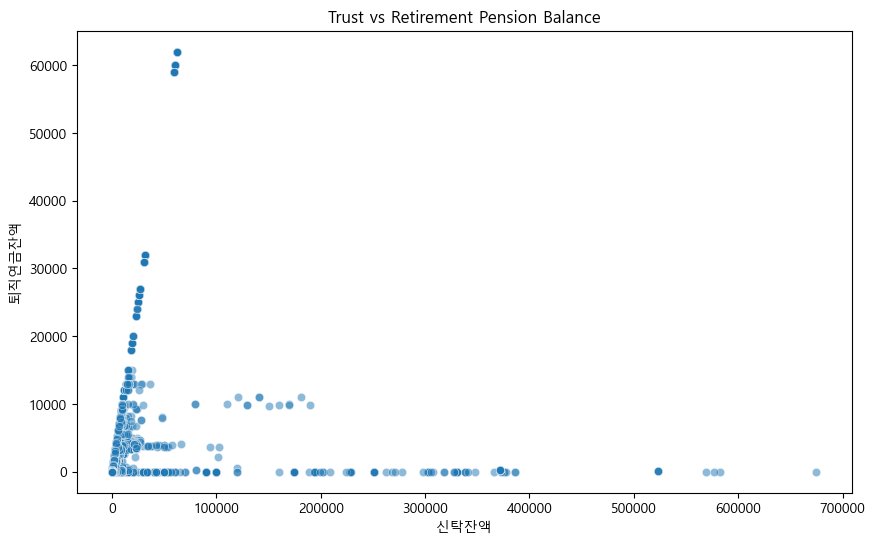

In [280]:
# 1. 상관관계 계산 (피어슨 상관계수)
correlation = df2['신탁잔액'].corr(df2['퇴직연금잔액'])
print(f"신탁잔액과 퇴직연금의 상관계수: {correlation:.4f}")

# 2. 산점도(Scatter Plot)로 시각화해서 '고래'들 확인하기
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df2, x='신탁잔액', y='퇴직연금잔액', alpha=0.5)
plt.title('Trust vs Retirement Pension Balance')
plt.show()

In [281]:
# 1. 퇴직연금이 있는 기업만 필터링 (0인 기업들 때문에 상관계수가 낮아질 수 있으므로)
pension_exist = df2[df2['퇴직연금잔액'] > 0].copy()
total_pension_firms = len(pension_exist)

# 2. 가설 1: 신탁잔액이 퇴직연금잔액과 동일하거나 더 큰 경우
trust_gte_pension = pension_exist[pension_exist['신탁잔액'] >= pension_exist['퇴직연금잔액']].shape[0]

# 3. 가설 2: 신탁잔액과 퇴직연금잔액이 완전히 동일한 경우 (세트 상품 여부 확인)
trust_eq_pension = pension_exist[pension_exist['신탁잔액'] == pension_exist['퇴직연금잔액']].shape[0]

# 4. 가설 3: 퇴직연금은 있는데 신탁은 0인 경우 (이탈 혹은 미가입)
trust_zero = pension_exist[pension_exist['신탁잔액'] == 0].shape[0]

print(f"--- 신탁 vs 퇴직연금 잔액 가설 검증 (퇴직연금 보유 기업 기준) ---")
print(f"1. 퇴직연금 보유 기업 수: {total_pension_firms}개")
print(f"2. 신탁 >= 퇴직연금: {trust_gte_pension}개 ({(trust_gte_pension/total_pension_firms)*100:.2f}%)")
print(f"3. 신탁 == 퇴직연금: {trust_eq_pension}개 ({(trust_eq_pension/total_pension_firms)*100:.2f}%)")
print(f"4. 퇴직연금은 있는데 신탁은 0인 기업: {trust_zero}개 ({(trust_zero/total_pension_firms)*100:.2f}%)")

# 추가: 퇴직연금 보유 기업들만의 상관계수 재산출
sub_corr = pension_exist['신탁잔액'].corr(pension_exist['퇴직연금잔액'])
print(f"\n* 퇴직연금 보유 기업 내에서의 상관계수: {sub_corr:.4f}")

--- 신탁 vs 퇴직연금 잔액 가설 검증 (퇴직연금 보유 기업 기준) ---
1. 퇴직연금 보유 기업 수: 67225개
2. 신탁 >= 퇴직연금: 67225개 (100.00%)
3. 신탁 == 퇴직연금: 61503개 (91.49%)
4. 퇴직연금은 있는데 신탁은 0인 기업: 0개 (0.00%)

* 퇴직연금 보유 기업 내에서의 상관계수: 0.3229


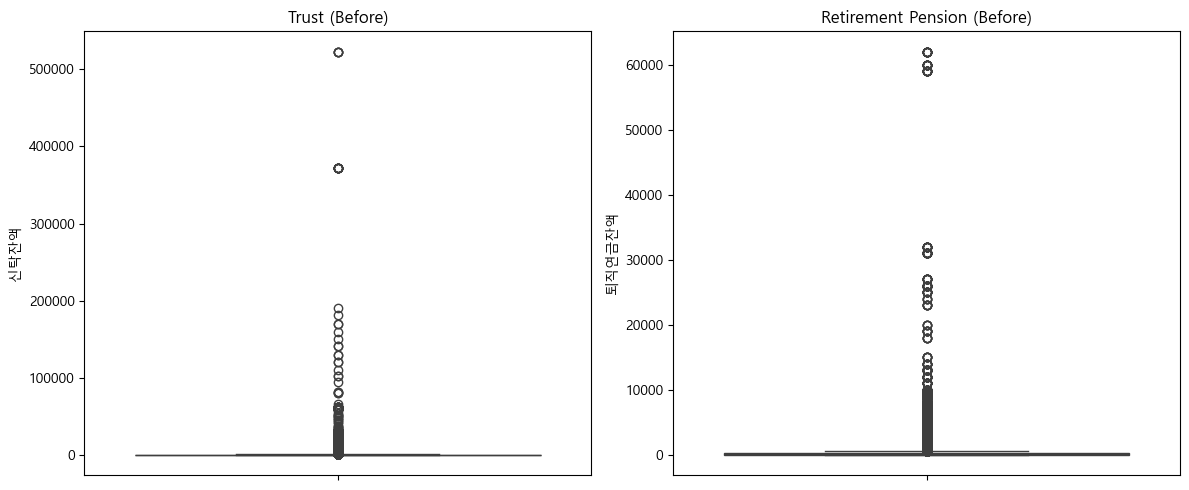

--- 아웃라이어(상위 5%) 제거 후 결과 ---
정제된 데이터 수: 63372개
정제 후 상관계수: 0.9209


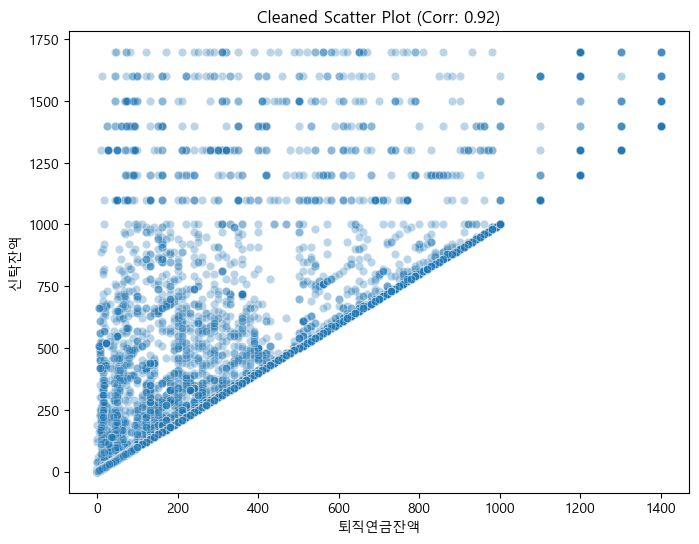

In [283]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 퇴직연금 보유 그룹 추출
pension_exist = df2[df2['퇴직연금잔액'] > 0].copy()

# 2. 박스플롯으로 아웃라이어 시각화 (제거 전)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=pension_exist['신탁잔액'])
plt.title('Trust (Before)')

plt.subplot(1, 2, 2)
sns.boxplot(y=pension_exist['퇴직연금잔액'])
plt.title('Retirement Pension (Before)')
plt.tight_layout()
plt.show()

# 3. IQR 방식으로 아웃라이어 제거 (상위 95% 혹은 IQR 사용)
# 여기서는 95% 백분위수로 더 과감하게 잘라볼게요 (진짜 거물들만 제외)
q_limit_trust = pension_exist['신탁잔액'].quantile(0.95)
q_limit_pension = pension_exist['퇴직연금잔액'].quantile(0.95)

# 두 잔액 모두 상위 5% 안에 들지 않는 '일반 기업'들만 필터링
pension_cleaned = pension_exist[
    (pension_exist['신탁잔액'] <= q_limit_trust) & 
    (pension_exist['퇴직연금잔액'] <= q_limit_pension)
]

# 4. 정제된 데이터로 상관계수 재계산
new_corr = pension_cleaned['신탁잔액'].corr(pension_cleaned['퇴직연금잔액'])

print(f"--- 아웃라이어(상위 5%) 제거 후 결과 ---")
print(f"정제된 데이터 수: {len(pension_cleaned)}개")
print(f"정제 후 상관계수: {new_corr:.4f}")

# 5. 정제 후 산점도 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pension_cleaned, x='퇴직연금잔액', y='신탁잔액', alpha=0.3)
plt.title(f'Cleaned Scatter Plot (Corr: {new_corr:.2f})')
plt.show()

In [282]:
# 신탁이 퇴직연금보다 많은 '진짜 부자'들만 추출
vip_firms = df2[df2['신탁잔액'] > df2['퇴직연금잔액']].copy()

# 이들의 '법인고객등급' 분포를 보세요.
print("--- 신탁 거물들의 고객 등급 분포 ---")
print(vip_firms['법인_고객등급'].value_counts())

# 이들의 '평균 총자산' 규모는?
print(f"\n거물 기업 평균 자산: {vip_firms['총자산'].mean():.2f}")

--- 신탁 거물들의 고객 등급 분포 ---
법인_고객등급
최우수    11360
우수      2250
일반       609
Name: count, dtype: int64

거물 기업 평균 자산: 4215.90


In [277]:
# 1. 예대마진 비율 (이자이익 / 총자산)
# 예대마진n이 백만원 단위 금액이라면 아래와 같이 계산
df2['이자수익비율'] = df2['예대마진n'] / (df2['총자산'] + 1)

# 2. 비이자수익 비율 (추정 비이자수익 / 총자산)
df2['비이자수익비율'] = df2['추정_비이자수익'] / (df2['총자산'] + 1)

# 3. 종합 수익성 지표 (비율 + 비율)
df2['종합수익성지표'] = df2['이자수익비율'] + df2['비이자수익비율']

# 4. 검증: 0보다 작은 놈들이 몇 개나 살아남았는지 확인
neg_count = len(df2[df2['종합수익성지표'] < 0])
print(f"새 지표 기준 비용유발형(음수) 기업 수: {neg_count}개")

새 지표 기준 비용유발형(음수) 기업 수: 16483개


In [279]:
df2['추정_비이자수익'].describe()

count    347299.000000
mean          1.139412
std          18.961212
min           0.000000
25%           0.000000
50%           0.019526
75%           0.119567
max        2039.175000
Name: 추정_비이자수익, dtype: float64

In [255]:
df2["고객유형"] = np.where(df2["예대마진n"] > 0, "수익 주도형", "비용 유발형") 

In [256]:
df2["고객유형"].value_counts()

고객유형
수익 주도형    305151
비용 유발형     42148
Name: count, dtype: int64

In [257]:
df2.isnull().sum()

기준년월           0
업종_대분류         0
업종_중분류         0
사업장_시도         0
사업장_시군구        0
              ..
예대마진(%)        0
예금이자           0
대출이자           0
예대마진n          0
예대마진수익률n(%)    0
Length: 66, dtype: int64

In [258]:
df2['예대마진수익률n(%)'].value_counts()

예대마진수익률n(%)
 0.035000    5228
 0.038333    4176
-0.025000    3606
-0.023333    2939
 0.037500    2540
             ... 
 0.028543       1
 0.026259       1
 0.022124       1
 0.033979       1
 0.027393       1
Name: count, Length: 177292, dtype: int64

(array([ 3000.,  1546.,  5939.,  3796.,  6034.,  1265.,   502.,  1984.,
         1278.,  1337.,  1444.,  2888.,   912.,   963.,  1029.,  1021.,
         1027.,  1123.,  1176.,  1181.,  3267.,  1335.,  1488.,  1600.,
         1864.,  1901.,  1948.,  2082.,  2274.,  2466.,  2812.,  2900.,
         3249.,  3506.,  3934.,  4578.,  5992., 11377.,  9774., 11124.,
        12862., 13938., 15631., 12407., 31445., 38399., 26225., 40650.,
        32596.,  4230.]),
 array([-0.35 , -0.333, -0.316, -0.299, -0.282, -0.265, -0.248, -0.231,
        -0.214, -0.197, -0.18 , -0.163, -0.146, -0.129, -0.112, -0.095,
        -0.078, -0.061, -0.044, -0.027, -0.01 ,  0.007,  0.024,  0.041,
         0.058,  0.075,  0.092,  0.109,  0.126,  0.143,  0.16 ,  0.177,
         0.194,  0.211,  0.228,  0.245,  0.262,  0.279,  0.296,  0.313,
         0.33 ,  0.347,  0.364,  0.381,  0.398,  0.415,  0.432,  0.449,
         0.466,  0.483,  0.5  ]),
 <BarContainer object of 50 artists>)

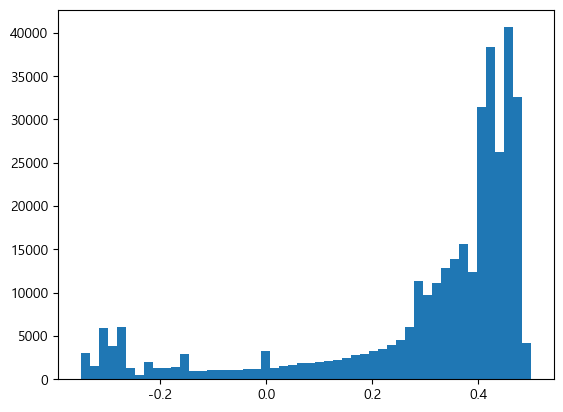

In [84]:
plt.hist(x='예대마진수익률n(%)',data=df2, bins=50)

In [113]:
a= df2[df2['예대마진수익률n(%)'] > 0.4]

In [114]:
a['법인_고객등급'].value_counts()

법인_고객등급
최우수    59787
일반     56837
우수     54832
Name: count, dtype: int64

In [ ]:
c= a[(a['요구불예금잔액'] == 0) & (a['총대출잔액'] < 0.4)]

In [214]:
c.shape

(1056, 66)

In [68]:
c.head(10)

,기준년월,업종_대분류,업종_중분류,사업장_시도,사업장_시군구,법인_고객등급,전담고객여부,요구불예금잔액,거치식예금잔액,적립식예금잔액,수익증권잔액,신탁잔액,퇴직연금잔액,여신한도금액,여신_운전자금대출잔액,여신_시설자금대출잔액,외환_수출실적금액,외환_수입실적금액,신용카드사용금액,체크카드사용금액,창구거래금액,인터넷뱅킹거래금액,스마트뱅킹거래금액,폰뱅킹거래금액,ATM거래금액,자동이체금액,요구불입금금액,요구불출금금액,요구불예금좌수,거치식예금좌수,적립식예금좌수,수익증권좌수,신탁좌수,퇴직연금좌수,여신_운전자금대출좌수,여신_시설자금대출좌수,신용카드개수,외환_수출실적거래건수,외환_수입실적거래건수,창구거래건수,인터넷뱅킹거래건수,스마트뱅킹거래건수,폰뱅킹거래건수,ATM거래건수,자동이체거래건수,총예금잔액,자산관리잔액,총대출잔액,총예금좌수,총대출좌수,자산관리좌수,총요구불입출금,전체거래액,총디지털거래액,총오프라인거래액,총카드소비,총외환실적,예대마진,고객유형,평균대출금리(%),평균예금금리(%),예대마진(%),예금이자,대출이자,예대마진n,예대마진수익률n(%)
48,202412,부동산업,부동산업,대구광역시,서구,일반,N,0.0,0.0,0.0,0.0,0.0,0.0,90.0,5.70,0.0,0.0,0.0,0.08,0.0,1.9,0.00,0.47,0.0,0.00,1.10,0.64,2.80,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,15.0,0.0,0.0,5.70,2.0,1.0,0.0,3.44,2.37,0.47,1.90,0.08,0.0,0.2850,수익 주도형,4.92,3.15,1.77,0.0,0.280440,0.280440,4.92
191,202412,도매 및 소매업,도매 및 상품 중개업,대구광역시,서구,일반,N,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.00,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.00,0.00,0.00,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.00,2.0,1.0,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.2000,수익 주도형,4.92,3.15,1.77,0.0,0.196800,0.196800,4.92
233,202412,제조업,섬유제품 제조업; 의복제외,대구광역시,서구,일반,N,0.0,0.0,0.0,0.0,0.0,0.0,120.0,5.20,0.0,0.0,0.0,3.00,0.0,0.0,47.00,0.00,0.0,0.22,5.50,6.30,53.00,4.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,4.0,0.0,0.0,0.0,15.0,0.0,0.0,3.5,15.0,0.0,0.0,5.20,4.0,2.0,0.0,59.30,47.22,47.00,0.22,3.00,0.0,0.2600,수익 주도형,4.92,3.15,1.77,0.0,0.255840,0.255840,4.92
702,202412,도매 및 소매업,도매 및 상품 중개업,대구광역시,동구,일반,N,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.99,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.21,0.00,0.21,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.5,0.0,0.0,0.99,1.0,1.0,0.0,0.21,0.00,0.00,0.00,0.00,0.0,0.0495,수익 주도형,4.92,3.15,1.77,0.0,0.048708,0.048708,4.92
987,202412,건설업,전문직별 공사업,대구광역시,동구,일반,N,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.60,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.00,0.00,0.00,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.60,2.0,1.0,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0800,수익 주도형,4.92,3.15,1.77,0.0,0.078720,0.078720,4.92
1125,202412,금융 및 보험업,금융 및 보험 관련 서비스업,대구광역시,중구,일반,N,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.70,0.0,0.0,0.0,0.00,0.0,0.0,0.92,0.00,0.0,0.41,0.60,0.10,1.90,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.5,3.5,0.0,0.0,3.70,2.0,1.0,0.0,2.00,1.33,0.92,0.41,0.00,0.0,0.1850,수익 주도형,4.92,3.15,1.77,0.0,0.182040,0.182040,4.92
1474,202412,"사업시설 관리, 사업 지원 및 임대 서비스업",사업지원 서비스업,대구광역시,중구,일반,N,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.41,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.00,0.00,0.00,4.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.41,4.0,4.0,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0205,수익 주도형,4.92,3.15,1.77,0.0,0.020172,0.020172,4.92
1557,202412,제조업,고무 및 플라스틱제품 제조업,경기도,화성시,일반,Y,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.00,0.0,0.0,0.0,9.90,0.0,0.0,2.00,0.00,0.0,0.00,6.70,8.70,8.70,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,15.5,0.0,0.0,0.0,7.5,0.0,0.0,0.0,7.5,0.0,0.0,3.00,1.0,1.0,0.0,17.40,2.00,2.00,0.00,9.90,0.0,0.1500,수익 주도형,4.92,3.15,1.77,0.0,0.147600,0.147600,4.92
1623,202412,건설업,종합 건설업,대구광역시,달성군,우수,Y,0.0,0.0,0.0,0.0,1.0,0.0,30.0,3.80,0.0,0.0,0.0,1.50,0.0,0.0,400.00,0.00,0.0,0.00,3.40,200.00,210.00,4.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,15.0,0.0,0.0,0.0,25.0,0.0,1.0,3.80,4.0,1.0,1.0,410.00,400.00,400.00,0.00,1.50,0.0,0.1900,수익 주도형,4.92,3.15,1.77,0.0,0.186960,0.186960,4.92
1811,202412,도매 및 소매업,도매 및 상품 중개업,대구광역시,달성군,일반,N,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.60,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.00,0.00,0.00,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.60,2.0,1.0,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0800,수익 주도형,4.92,3.15,1.77,0.0,0.078720,0.078720,4.92


In [69]:
b= a[a['예대마진n']==0.000501]

In [ ]:
pd.set_option('display.max_columns', None)
b
# 만원을 빌렸는데? 대출이자가 500원이야...
# 근데 예대마진수익률이 5%면 사실 개높다고 생각했는데, 사실 만원을 빌리고 대출이자가 500원이어서 예대마진(%)이 5%나 나온거임
# 이런건 수익률이 높다고 치기도, 수익이라고하기도 애매하지않나. 이런거 좀 걸러내는 로직이 필요해보임

,기준년월,업종_대분류,업종_중분류,사업장_시도,사업장_시군구,법인_고객등급,전담고객여부,요구불예금잔액,거치식예금잔액,적립식예금잔액,수익증권잔액,신탁잔액,퇴직연금잔액,여신한도금액,여신_운전자금대출잔액,여신_시설자금대출잔액,외환_수출실적금액,외환_수입실적금액,신용카드사용금액,체크카드사용금액,창구거래금액,인터넷뱅킹거래금액,스마트뱅킹거래금액,폰뱅킹거래금액,ATM거래금액,자동이체금액,요구불입금금액,요구불출금금액,요구불예금좌수,거치식예금좌수,적립식예금좌수,수익증권좌수,신탁좌수,퇴직연금좌수,여신_운전자금대출좌수,여신_시설자금대출좌수,신용카드개수,외환_수출실적거래건수,외환_수입실적거래건수,창구거래건수,인터넷뱅킹거래건수,스마트뱅킹거래건수,폰뱅킹거래건수,ATM거래건수,자동이체거래건수,총예금잔액,자산관리잔액,총대출잔액,총예금좌수,총대출좌수,자산관리좌수,총요구불입출금,전체거래액,총디지털거래액,총오프라인거래액,총카드소비,총외환실적,예대마진,고객유형,평균대출금리(%),평균예금금리(%),예대마진(%),예금이자,대출이자,예대마진n,예대마진수익률n(%)
20560,202410,정보통신업,정보서비스업,서울특별시,금천구,일반,N,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.01,0.0,0.01,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.5,0.0,0.0,0.01,1.0,1.0,0.0,0.01,0.0,0.0,0.0,0.0,0.0,0.0005,수익 주도형,5.01,3.38,1.63,0.0,0.000501,0.000501,5.01


🛠️ 1. '최소 규모(Floor)' 필터링 (가장 확실함)
수익률을 계산하기 전에, 대출이나 예금의 절대 규모가 일정 수준 이상인 애들만 대상으로 삼는 겁니다.

로직: 총대출잔액 > 1,000만원 (또는 주희님 데이터의 하위 10~20% 지점)

이유: "최소한 이 정도 체급은 되어야 수익률을 논할 가치가 있다"는 기준을 세우는 거죠.

🛠️ 2. '수익금(NIM Amount)' 지표 병행 사용
수익률(%)만 보지 말고, 실제 은행 주머니에 들어오는 '절대 수익금' 컬럼을 하나 더 만드세요.

공식: 실질수익금 = (총대출잔액 * 대출금리) - (총예금잔액 * 예금원가)

판단: 수익률이 5%라도 수익금이 500원인 놈 vs 수익률은 1%지만 수익금이 1억인 놈. 당연히 후자가 진짜 우량 고객입니다.

🛠️ 3. 가중치 적용 (Weighted Score)
주희님이 만들고 계신 '우량성 점수'에 규모(Size) 가중치를 주는 방식입니다.

아이디어: 우량성 점수 = (예대마진% * 0.4) + (총자산규모_로그값 * 0.6)

이렇게 하면 500원 벌어다 주는 기업은 점수가 확 낮아지고, 덩치가 큰 기업들이 상위권으로 올라옵니다.

In [117]:
a.describe()

,기준년월,요구불예금잔액,거치식예금잔액,적립식예금잔액,수익증권잔액,신탁잔액,퇴직연금잔액,여신한도금액,여신_운전자금대출잔액,여신_시설자금대출잔액,외환_수출실적금액,외환_수입실적금액,신용카드사용금액,체크카드사용금액,창구거래금액,인터넷뱅킹거래금액,스마트뱅킹거래금액,폰뱅킹거래금액,ATM거래금액,자동이체금액,요구불입금금액,요구불출금금액,요구불예금좌수,거치식예금좌수,적립식예금좌수,수익증권좌수,신탁좌수,퇴직연금좌수,여신_운전자금대출좌수,여신_시설자금대출좌수,신용카드개수,외환_수출실적거래건수,외환_수입실적거래건수,창구거래건수,인터넷뱅킹거래건수,스마트뱅킹거래건수,폰뱅킹거래건수,ATM거래건수,자동이체거래건수,총예금잔액,자산관리잔액,총대출잔액,총예금좌수,총대출좌수,자산관리좌수,총요구불입출금,전체거래액,총디지털거래액,총오프라인거래액,총카드소비,총외환실적,예대마진,평균대출금리(%),평균예금금리(%),예대마진(%),예금이자,대출이자,예대마진n,예대마진수익률n(%)
count,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,1.714560e+05,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,1.714560e+05,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,1.714560e+05,1.714560e+05,1.714560e+05,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000,171456.000000
mean,202328.387598,19.233473,1.580957,1.109638,0.618474,136.104006,44.205297,566.082221,977.107030,1049.664460,0.012119,0.011925,4.427719,0.072690,49.327568,2.830243e+02,9.861313,1.720361,93.386103,76.098105,365.469550,4.414755e+02,3.079939,0.028348,0.063083,0.026628,0.240671,0.192411,5.255538,0.814617,3.636230,0.091088,0.088897,1.005608,15.627123,2.235871,0.346211,1.490251,15.218432,21.924067,180.927778,2026.771489,3.171370,6.070155,0.459710,8.069451e+02,4.373197e+02,2.946060e+02,142.713671,4.500409,0.024044,100.577809,0.451292,0.300017,0.151756,0.067497,9.135857,9.068359,0.442358
std,69.812108,145.813790,40.439516,18.085960,20.292847,5020.524082,447.585317,3329.671570,3887.432753,3682.803488,0.296245,0.372015,39.900564,2.279537,893.666397,7.240371e+03,69.263509,26.221459,1663.198736,1240.714838,3224.721669,7.965932e+03,3.282186,0.250129,0.480671,0.282583,0.610696,0.435367,9.898136,1.487714,5.201803,1.164079,0.792591,4.678316,20.828787,7.338818,2.651180,5.223472,14.271421,159.212243,5085.796258,5569.365519,3.367114,10.137673,1.050981,9.963078e+03,7.997022e+03,7.241280e+03,2071.948509,40.104035,0.504234,275.679689,0.024894,0.027165,0.017410,0.500674,25.188847,24.933422,0.025021
min,202208.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.010000,0.000000,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000500,0.410000,0.230000,0.110000,0.000000,0.000042,0.000042,0.400000
25%,202303.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,1.800000,2.800000,4.000000e+00,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.500000,0.050000,0.000000,140.000000,1.000000,1.000000,0.000000,7.800000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,6.871610,0.420000,0.280000,0.140000,0.000145,0.615000,0.610349,0.419553
50%,202309.000000,0.970000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,200.000000,0.000000,0.000000,0.000000,0.330000,0.000000,0.000000,5.900000e+00,0.000000,0.000000,0.000000,7.800000,26.000000,3.100000e+01,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,2.000000,0.000000,0.000000,0.000000,3.500000,0.000000,0.000000,0.000000,15.000000,1.000

In [123]:
df2['예대마진n'].describe()

count    347299.000000
mean          4.827560
std         113.652396
min      -19204.147200
25%           0.186405
50%           1.228272
75%           4.920000
max        1049.010000
Name: 예대마진n, dtype: float64

<Axes: xlabel='예대마진n'>

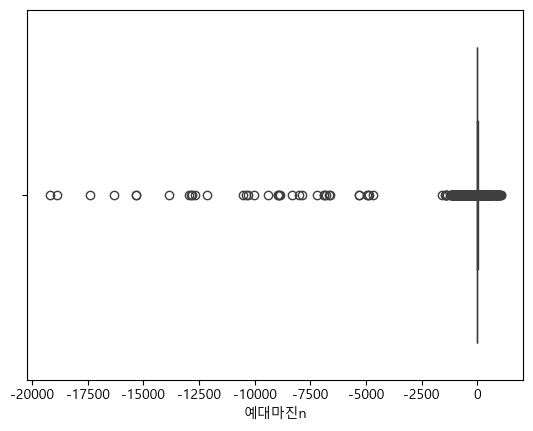

In [124]:
sns.boxplot(x='예대마진n', data=df2)

In [125]:
aa= df2[df2['예대마진n']<-2500]

In [136]:
df2.describe().round(2)

,기준년월,요구불예금잔액,거치식예금잔액,적립식예금잔액,수익증권잔액,신탁잔액,퇴직연금잔액,여신한도금액,여신_운전자금대출잔액,여신_시설자금대출잔액,외환_수출실적금액,외환_수입실적금액,신용카드사용금액,체크카드사용금액,창구거래금액,인터넷뱅킹거래금액,스마트뱅킹거래금액,폰뱅킹거래금액,ATM거래금액,자동이체금액,요구불입금금액,요구불출금금액,요구불예금좌수,거치식예금좌수,적립식예금좌수,수익증권좌수,신탁좌수,퇴직연금좌수,여신_운전자금대출좌수,여신_시설자금대출좌수,신용카드개수,외환_수출실적거래건수,외환_수입실적거래건수,창구거래건수,인터넷뱅킹거래건수,스마트뱅킹거래건수,폰뱅킹거래건수,ATM거래건수,자동이체거래건수,총예금잔액,자산관리잔액,총대출잔액,총예금좌수,총대출좌수,자산관리좌수,총요구불입출금,전체거래액,총디지털거래액,총오프라인거래액,총카드소비,총외환실적,예대마진,평균대출금리(%),평균예금금리(%),예대마진(%),예금이자,대출이자,예대마진n,예대마진수익률n(%)
count,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00
mean,202306.94,162.04,610.57,3.89,0.84,233.10,79.61,646.39,823.20,806.52,0.02,0.02,5.97,0.16,254.44,804.16,13.46,2.99,110.41,195.27,906.86,1156.40,3.75,0.21,0.13,0.04,0.31,0.24,4.89,0.68,4.31,0.13,0.12,1.74,20.83,2.87,0.56,1.92,17.12,776.50,313.55,1629.72,4.09,5.57,0.59,2063.26,1185.46,820.61,364.85,6.13,0.03,54.54,0.43,0.27,0.15,2.15,6.98,4.83,0.30
std,81.71,2441.79,40304.21,40.73,22.67,5569.77,888.43,4853.18,3886.92,3810.15,0.41,0.39,113.28,2.59,18745.79,25270.54,135.00,38.76,2024.74,4089.33,22108.44,29334.98,4.59,1.84,0.77,0.36,0.84,0.48,9.42,1.41,5.96,1.58,1.01,6.42,22.62,8.59,3.68,6.13,14.96,40416.68,5795.17,5654.21,5.27,9.66,1.29,48511.33,34957.43,25275.01,18920.43,113.39,0.59,1352.35,0.05,0.05,0.02,117.80,24.54,113.65,0.22
min,202201.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-202001.65,0.29,0.15,0.11,0.00,0.00,-19204.15,-0.35
25%,202210.00,0.34,0.00,0.00,0.00,0.00,0.00,0.00,17.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.40,5.70,7.80,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.50,0.40,0.00,64.00,1.00,1.00,0.00,15.80,1.00,0.00,0.00,0.00,0.00,2.15,0.41,0.27,0.14,0.00,0.27,0.19,0.28
50%,202307.00,6.60,0.00,0.00,0.00,0.00,0.00,0.00,150.00,0.00,0.00,0.00,1.00,0.00,0.00,28.00,0.00,0.00,0.00,9.50,56.00,62.00,2.00,0.00,0.00,0.00,0.00,0.00,2.00,0.00,2.00,0.00,0.00,0.00,7.50,0.00,0.00,0.00,15.00,8.10,0.00,320.00,2.00,2.00,0.00,125.00,52.90,39.00,0.00,1.10,0.00,14.49,0.44,0.29,0.15,0.02,1.39,1.23,0.40
75%,202404.00,55.00,0.00,0.00,0.00,0.00,0.00,200.00,520.00,350.00,0.00,0.00,4.60,0.00,0.11,180.00,0.63,0.00,0.30,30.00,250.00,260.00,4.00,0.00,0.00,0.00,0.00,0.00,4.00,1.00,4.00,0.00,0.00,1.00,45.00,1.00,0.00,1.00,25.00,68.00,0.00,1230.00,4.00,5.00,1.00,520.00,250.36,200.00,5.00,4.70,0.00,58.34,0.47,0.30,0.17,0.18,5.28,4.92,0.44
max,202412.00,304000.00,6026000.00,3400.00,3400.00,675000.00,62000.00,300000.00,245000.00,273000.00,65.00,81.00,26000.00,790.00,7619000.00,2162000.00,24000.00,6800.00,259000.00,292000.00,5172000.00,5192000.00,55.00,55.00,35.50,15.50,45.50,4.00,55.00,25.50,55.00,55.00,55.00,55.00,55.00,55.00,55.00,55.00,55.00,6026000.00,675000.00,273000.00,114.00,70.50,45.50,10364000.00,9010000.00,2162000.00,7619000.00,26000.00,81.00,11735.40,0.50,0.35,0.19,19885.80,1146.60,1049.01,0.50


In [143]:
aa.describe()

,기준년월,요구불예금잔액,거치식예금잔액,적립식예금잔액,수익증권잔액,신탁잔액,퇴직연금잔액,여신한도금액,여신_운전자금대출잔액,여신_시설자금대출잔액,외환_수출실적금액,외환_수입실적금액,신용카드사용금액,체크카드사용금액,창구거래금액,인터넷뱅킹거래금액,스마트뱅킹거래금액,폰뱅킹거래금액,ATM거래금액,자동이체금액,요구불입금금액,요구불출금금액,요구불예금좌수,거치식예금좌수,적립식예금좌수,수익증권좌수,신탁좌수,퇴직연금좌수,여신_운전자금대출좌수,여신_시설자금대출좌수,신용카드개수,외환_수출실적거래건수,외환_수입실적거래건수,창구거래건수,인터넷뱅킹거래건수,스마트뱅킹거래건수,폰뱅킹거래건수,ATM거래건수,자동이체거래건수,총예금잔액,자산관리잔액,총대출잔액,총예금좌수,총대출좌수,자산관리좌수,총요구불입출금,전체거래액,총디지털거래액,총오프라인거래액,총카드소비,총외환실적,예대마진,평균대출금리(%),평균예금금리(%),예대마진(%),예금이자,대출이자,예대마진n,예대마진수익률n(%)
count,36.000000,36.000000,3.600000e+01,36.0,36.0,36.0,36.0,36.000000,36.000000,36.000000,36.0,36.0,36.0,36.0,3.600000e+01,36.0,36.0,36.0,36.000000,36.000000,36.000000,36.000000,36.0,36.0,36.0,36.0,36.0,36.0,36.0,36.000000,36.0,36.0,36.0,36.000000,36.0,36.0,36.0,36.000000,36.0,3.600000e+01,36.0,36.000000,36.0,36.000000,36.0,36.000000,3.600000e+01,36.0,3.600000e+01,36.0,36.0,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000
mean,202306.500000,2150.000000,3.771972e+06,0.0,0.0,0.0,0.0,1611.111111,5.293333,129555.555556,0.0,0.0,0.0,0.0,6.616667e+05,0.0,0.0,0.0,0.012778,2245.944444,16398.055556,89.523056,4.0,55.0,0.0,0.0,0.0,0.0,1.0,5.111111,0.0,0.0,0.0,17.583333,0.0,0.0,0.0,0.055556,55.0,3.774122e+06,0.0,129560.848889,59.0,6.111111,0.0,16487.578611,6.616667e+05,0.0,6.616667e+05,0.0,0.0,-124483.998667,0.426944,0.274444,0.153056,10591.638611,554.113028,-10037.525583,-0.250409
std,82.881844,3587.000339,9.731001e+05,0.0,0.0,0.0,0.0,802.772972,5.528337,6231.002875,0.0,0.0,0.0,0.0,4.230250e+05,0.0,0.0,0.0,0.076667,3036.779252,50557.782886,371.542309,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.817027,0.0,0.0,0.0,11.594026,0.0,0.0,0.0,0.333333,0.0,9.720352e+05,0.0,6234.846739,0.0,1.817027,0.0,50535.386882,4.230250e+05,0.0,4.230250e+05,0.0,0.0,33480.631357,0.052198,0.055366,0.016873,4191.358934,80.050487,4119.988962,0.053936
min,202201.000000,0.000000,2.683000e+06,0.0,0.0,0.0,0.0,0.000000,0.000000,114000.000000,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.000000,46.000000,230.000000,0.000000,4.0,55.0,0.0,0.0,0.0,0.0,1.0,4.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,55.0,2.683000e+06,0.0,114000.000000,59.0,5.000000,0.0,230.690000,0.000000e+00,0.0,0.000000e+00,0.0,0.0,-202001.650000,0.290000,0.150000,0.110000,5100.800000,368.300000,-19204.147200,-0.326992
25%,202209.750000,0.000000,3.088500e+06,0.0,0.0,0.0,0.0,2000.000000,0.000000,127000.000000,0.0,0.0,0.0,0.0,3.750000e+05,0.0,0.0,0.0,0.000000,1070.000000,472.500000,0.505000,4.0,55.0,0.0,0.0,0.0,0.0,1.0,4.000000,0.0,0.0,0.0,7.500000,0.0,0.0,0.0,0.000000,55.0,3.089225e+06,0.0,127000.000000,59.0,5.000000,0.0,472.995000,3.750000e+05,0.0,3.750000e+05,0.0,0.0,-145929.288750,0.410000,0.267500,0.140000,7377.412500,520.700000,-12822.478640,-0.280790
50%,202306.500000,0.000000,3.398000e+06,0.0,0.0,0.0,0.0,2000.000000,3.750000,127000.000000,0.0,0.0,0.0,0.0,5.650000e+05,0.0,0.0,0.0,0.000000,1500.000000,3100.000000,0.690000,4.0,55.0,0.0,0.0,0.0,0.0,1.0,4.000000,0.0,0.0,0.0,15.000000,0.0,0.0,0.0,0.000000,55.0,3.399150e+06,0.0,127003.750000,59.0,5.000000,0.0,3150.360000,5.650000e+05,0.0,5.650000e+05,0.0,0.0,-111600.317500,0.440000,0.290000,0.150000,9517.620000,569.599700,-8958.802750,-0.258954
75%,202403.250000,6300.000000,4.386750e+06,0.0,0.0,0.0,0.0,2000.000000,9.700000,128250.000000,0.0,0.0,0.0,0.0,9.552500e+05,0.0,0.0,0.0,0.000000,2500.000000,5950.000000,0.722500,4.0,55.0,0.0,0.0,0.0,0.0,1.0,8.000000,0.0,0.0,0.0,25.000000,0.0,0.0,0.0,0.000000,55.0,4.393875e+06,0.0,128260.950000,59.0,9.000000,0.0,6700.000000,9.552500e+05,0.0,9.552500e+05,0.0,0.0,-100846.082750,0.462500,0.300000,0.170000,13432.100000,600.107985,-6853.537500,-0.237259
max,202412.000000,9500.000000,6.026000e+06,0.0,0.0,0.0,0.0,2000.000000,16.000000,142000.000000,0.0,0.0,0.0,0.0,1.920000e+06,0.0,0.0,0.0,0.460000,18000.000000,293000.000000,1600.000000,4.0,55.0,0.0,0.0,0.0,0.0,1.0,8.000000,0.0,0.0,0.0,45.000000,0.0,0.0,0.0,2.000000,55.0,6.026000e+06,0.0,142014.000000,59.0,9.000000,0.0,293000.710000,1.920000e+06,0.0,1.920000e+06,0.0,0.0,-86749.795000,0.50000

In [148]:
# '기준년월' 컬럼 기준 오름차순 정렬
aa = aa.sort_values(by='기준년월', ascending=True)

In [147]:
aa

,기준년월,업종_대분류,업종_중분류,사업장_시도,사업장_시군구,법인_고객등급,전담고객여부,요구불예금잔액,거치식예금잔액,적립식예금잔액,수익증권잔액,신탁잔액,퇴직연금잔액,여신한도금액,여신_운전자금대출잔액,여신_시설자금대출잔액,외환_수출실적금액,외환_수입실적금액,신용카드사용금액,체크카드사용금액,창구거래금액,인터넷뱅킹거래금액,스마트뱅킹거래금액,폰뱅킹거래금액,ATM거래금액,자동이체금액,요구불입금금액,요구불출금금액,요구불예금좌수,거치식예금좌수,적립식예금좌수,수익증권좌수,신탁좌수,퇴직연금좌수,여신_운전자금대출좌수,여신_시설자금대출좌수,신용카드개수,외환_수출실적거래건수,외환_수입실적거래건수,창구거래건수,인터넷뱅킹거래건수,스마트뱅킹거래건수,폰뱅킹거래건수,ATM거래건수,자동이체거래건수,총예금잔액,자산관리잔액,총대출잔액,총예금좌수,총대출좌수,자산관리좌수,총요구불입출금,전체거래액,총디지털거래액,총오프라인거래액,총카드소비,총외환실적,예대마진,고객유형,평균대출금리(%),평균예금금리(%),예대마진(%),예금이자,대출이자,예대마진n,예대마진수익률n(%)
319391,202201,금융 및 보험업,금융업,서울특별시,중구,최우수,N,0.0,3778000.0,0.0,0.0,0.0,0.0,2000.0,0.00,127000.0,0.0,0.0,0.0,0.0,175000.0,0.0,0.0,0.0,0.00,2500.0,510.0,0.66,4.0,55.0,0.0,0.0,0.0,0.0,1.0,4.0,0.0,0.0,0.0,7.5,0.0,0.0,0.0,0.0,55.0,3778000.0,0.0,127000.00,59.0,5.0,0.0,510.66,175000.00,0.0,175000.00,0.0,0.0,-124746.600,비용 유발형,0.29,0.15,0.15,5667.00,368.300000,-5298.700000,-0.135690
328828,202202,금융 및 보험업,금융업,서울특별시,중구,최우수,N,0.0,3494000.0,0.0,0.0,0.0,0.0,2000.0,0.00,127000.0,0.0,0.0,0.0,0.0,340000.0,0.0,0.0,0.0,0.00,1300.0,350.0,0.00,4.0,55.0,0.0,0.0,0.0,0.0,1.0,4.0,0.0,0.0,0.0,7.5,0.0,0.0,0.0,0.0,55.0,3494000.0,0.0,127000.00,59.0,5.0,0.0,350.00,340000.00,0.0,340000.00,0.0,0.0,-114891.800,비용 유발형,0.30,0.15,0.15,5241.00,381.000000,-4860.000000,-0.134217
338281,202203,금융 및 보험업,금융업,서울특별시,중구,최우수,N,0.0,3188000.0,0.0,0.0,0.0,0.0,2000.0,0.00,127000.0,0.0,0.0,0.0,0.0,630000.0,0.0,0.0,0.0,0.00,2500.0,290.0,0.00,4.0,55.0,0.0,0.0,0.0,0.0,1.0,4.0,0.0,0.0,0.0,15.0,0.0,0.0,0.0,0.0,55.0,3188000.0,0.0,127000.00,59.0,5.0,0.0,290.00,630000.00,0.0,630000.00,0.0,0.0,-104273.600,비용 유발형,0.33,0.16,0.17,5100.80,419.100000,-4681.700000,-0.141228
290842,202204,금융 및 보험업,금융업,서울특별시,중구,최우수,N,0.0,3158000.0,0.0,0.0,0.0,0.0,2000.0,0.00,127000.0,0.0,0.0,0.0,0.0,520000.0,0.0,0.0,0.0,0.00,1500.0,300.0,0.00,4.0,55.0,0.0,0.0,0.0,0.0,1.0,4.0,0.0,0.0,0.0,15.0,0.0,0.0,0.0,0.0,55.0,3158000.0,0.0,127000.00,59.0,5.0,0.0,300.00,520000.00,0.0,520000.00,0.0,0.0,-103232.600,비용 유발형,0.34,0.17,0.17,5368.60,431.800000,-4936.800000,-0.150283
300321,202205,금융 및 보험업,금융업,서울특별시,중구,최우수,N,0.0,3028000.0,0.0,0.0,0.0,0.0,2000.0,0.00,127000.0,0.0,0.0,0.0,0.0,527000.0,0.0,0.0,0.0,0.00,1500.0,330.0,0.00,4.0,55.0,0.0,0.0,0.0,0.0,1.0,4.0,0.0,0.0,0.0,45.0,0.0,0.0,0.0,0.0,55.0,3028000.0,0.0,127000.00,59.0,5.0,0.0,330.00,527000.00,0.0,527000.00,0.0,0.0,-98721.600,비용 유발형,0.36,0.19,0.17,5753.20,457.200000,-5296.000000,-0.167861
309903,202206,금융 및 보험업,금융업,서울특별시,중구,최우수,N,0.0,2686000.0,0.0,0.0,0.0,0.0,2000.0,0.00,127000.0,0.0,0.0,0.0,0.0,580000.0,0.0,0.0,0.0,0.00,1600.0,360.0,0.00,4.0,55.0,0.0,0.0,0.0,0.0,1.0,4.0,0.0,0.0,0.0,15.0,0.0,0.0,0.0,0.0,55.0,2686000.0,0.0,127000.00,59.0,5.0,0.0,360.00,580000.00,0.0,580000.00,0.0,0.0,-86854.200,비용 유발형,0.37,0.20,0.17,5372.00,469.900000,-4902.100000,-0.174266
261767,202207,금융 및 보험업,금융업,서울특별시,중구,최우수,N,0.0,3101000.0,0.0,0.0,0.0,0.0,2000.0,0.66,127000.0,0.0,0.0,0.0,0.0,490000.0,0.0,0.0,0.0,0.00,2300.0,240.0,0.66,4.0,55.0,0.0,0.0,0.0,0.0,1.0,4.0,0.0,0.0,0.0,15.0,0.0,0.0,0.0,0.0,55.0,3101000.0,0.0,127000.66,59.0,5.0,0.0,240.66,490000.00,0.0,490000.00,0.0,0.0,-101254.667,비용 유발형,0.37,0.23,0.14,7132.30,469.902442,-6662.397558,-0.206394
271473,202208,금융 및 보험업,금융업,서울특별시,중구,최우수,N,0.0,3111000.0,0.0,0.0,0.0,0.0,2000.0,1.30,127000.0,0.0,0.0,0.0,0.0,671000.0,0.0,0.0,0.0,0.00,2800.0,280.0,0.68,4.0,55.0,0.0,0.0,0.0,0.0,1.0,4.0,0.0,0.0,0.0,15.0,0.0,0.0,0.0,0.0,55.0,3111000.0,0.0,127001.30,59.0,5.0,0.0,280.68,671000.00,0.0,671000.00,0.0,0.0,-101601.635,비용 유발형,0.41,0.23,0.17,7155.30,520.705330,-6634.594670,-0.204898
281245,202209,금융 및 보험업,금융업,서울특별시,중구,최우수,N,0.0,3051000.0,0.0,0.0,0.0,0.0,2000.0,2.00,127000.0,0.0,0.0,0.0,0.0,770000.0,0.0,0.0,0.0,0.00,1700.0,230.0,0.69,4.0,55.0,0.0,0.0,0.0,0.0,1.0,4.0,0.0,0.0,0.0,15.0,0.0,0.0,0.0,0.0,55.0,3051000.0,0.0,127002.00,59.0,5.0,0.0,230.69,770000.00,0.0,770000.00,0.0,0.0,-99519.600,비용 유발형,0.42,0.29,0.13,8847.90,533.408400,-8314.491600,-0.261626
232527,202210,금융 및 보험업,금융업,서울특별시,중구,최우수,N,0.0,3175000.0,0.0,0.0,0.0,0.0,2000.0,2.70,127000.0,0.0

In [140]:
aa.head(2)

,기준년월,업종_대분류,업종_중분류,사업장_시도,사업장_시군구,법인_고객등급,전담고객여부,요구불예금잔액,거치식예금잔액,적립식예금잔액,수익증권잔액,신탁잔액,퇴직연금잔액,여신한도금액,여신_운전자금대출잔액,여신_시설자금대출잔액,외환_수출실적금액,외환_수입실적금액,신용카드사용금액,체크카드사용금액,창구거래금액,인터넷뱅킹거래금액,스마트뱅킹거래금액,폰뱅킹거래금액,ATM거래금액,자동이체금액,요구불입금금액,요구불출금금액,요구불예금좌수,거치식예금좌수,적립식예금좌수,수익증권좌수,신탁좌수,퇴직연금좌수,여신_운전자금대출좌수,여신_시설자금대출좌수,신용카드개수,외환_수출실적거래건수,외환_수입실적거래건수,창구거래건수,인터넷뱅킹거래건수,스마트뱅킹거래건수,폰뱅킹거래건수,ATM거래건수,자동이체거래건수,총예금잔액,자산관리잔액,총대출잔액,총예금좌수,총대출좌수,자산관리좌수,총요구불입출금,전체거래액,총디지털거래액,총오프라인거래액,총카드소비,총외환실적,예대마진,고객유형,평균대출금리(%),평균예금금리(%),예대마진(%),예금이자,대출이자,예대마진n,예대마진수익률n(%)
1522,202412,금융 및 보험업,금융업,서울특별시,중구,최우수,Y,6300.0,2835000.0,0.0,0.0,0.0,0.0,0.0,0.0,127000.0,0.0,0.0,0.0,0.0,440000.0,0.0,0.0,0.0,0.0,18000.0,4600.0,0.1,4.0,55.0,0.0,0.0,0.0,0.0,1.0,8.0,0.0,0.0,0.0,25.0,0.0,0.0,0.0,0.0,55.0,2841300.0,0.0,127000.0,59.0,9.0,0.0,4600.1,440000.0,0.0,440000.0,0.0,0.0,-92243.11,비용 유발형,0.41,0.26,0.15,7387.38,520.7,-6866.68,-0.231334
10086,202411,금융 및 보험업,금융업,서울특별시,중구,최우수,Y,6300.0,2736000.0,0.0,0.0,0.0,0.0,0.0,0.0,127000.0,0.0,0.0,0.0,0.0,250000.0,0.0,0.0,0.0,0.0,5800.0,2600.0,5.9,4.0,55.0,0.0,0.0,0.0,0.0,1.0,8.0,0.0,0.0,0.0,15.0,0.0,0.0,0.0,0.0,55.0,2742300.0,0.0,127000.0,59.0,9.0,0.0,2605.9,250000.0,0.0,250000.0,0.0,0.0,-88807.81,비용 유발형,0.41,0.27,0.14,7404.21,520.7,-6883.51,-0.239902


In [172]:
# 1. 가설 확인: 한도가 운전자금 잔액보다도 작은 경우 (한도 초과 혹은 다른 체계)
limit_less_than_operating = df2[df2['여신한도금액'] < df2['여신_운전자금대출잔액']].shape[0]

# 2. 비교군: 한도가 '총 대출잔액(운전+시설)'보다 작은 경우 (시설자금이 한도에 포함 안 됨을 증명)
limit_less_than_total = df2[df2['여신한도금액'] < df2['총대출잔액']].shape[0]

# 3. 전체 데이터 수 대비 비율 계산
total_count = len(df2)

print(f"--- 여신한도 가설 검증 결과 ---")
print(f"1. 전체 기업 수: {total_count}개")
print(f"2. 한도 < 운전자금잔액: {limit_less_than_operating}개 ({(limit_less_than_operating/total_count)*100:.2f}%)")
print(f"3. 한도 < 총대출잔액(운전+시설): {limit_less_than_total}개 ({(limit_less_than_total/total_count)*100:.2f}%)")

--- 여신한도 가설 검증 결과 ---
1. 전체 기업 수: 347299개
2. 한도 < 운전자금잔액: 228710개 (65.85%)
3. 한도 < 총대출잔액(운전+시설): 279782개 (80.56%)


In [149]:
# 1. VIP(고래) 그룹 따로 추출하여 보관
# (나중에 이 데이터만 가지고 'VIP 전용 리포트' 쓰시면 됩니다!)
df_vip = df2[df2['예대마진n'] < -2500].copy()

# 2. 일반 기업 그룹만 남기기 (분석용 데이터셋)
# 예대마진이 -2500 이상인 데이터들만 필터링
df3 = df2[df2['예대마진n'] >= -2500].copy()

# 3. 잘 분리됐는지 확인
print(f"전체 데이터 수: {len(df2)}")
print(f"분리된 VIP 수: {len(df_vip)}")
print(f"남은 일반 기업 수: {len(df3)}")

# 4. 일반 기업의 예대마진 평균 다시 확인 (이제 좀 사람 사는 숫자가 나올 거예요!)
print("\n=== 일반 기업 그룹 예대마진 기초 통계 ===")
print(df3['예대마진n'].describe())

전체 데이터 수: 347299
분리된 VIP 수: 36
남은 일반 기업 수: 347263

=== 일반 기업 그룹 예대마진 기초 통계 ===
count    347263.000000
mean          5.868629
std          27.413432
min       -1602.760000
25%           0.186595
50%           1.228623
75%           4.921175
max        1049.010000
Name: 예대마진n, dtype: float64


In [150]:
df3.describe().round(2)

,기준년월,요구불예금잔액,거치식예금잔액,적립식예금잔액,수익증권잔액,신탁잔액,퇴직연금잔액,여신한도금액,여신_운전자금대출잔액,여신_시설자금대출잔액,외환_수출실적금액,외환_수입실적금액,신용카드사용금액,체크카드사용금액,창구거래금액,인터넷뱅킹거래금액,스마트뱅킹거래금액,폰뱅킹거래금액,ATM거래금액,자동이체금액,요구불입금금액,요구불출금금액,요구불예금좌수,거치식예금좌수,적립식예금좌수,수익증권좌수,신탁좌수,퇴직연금좌수,여신_운전자금대출좌수,여신_시설자금대출좌수,신용카드개수,외환_수출실적거래건수,외환_수입실적거래건수,창구거래건수,인터넷뱅킹거래건수,스마트뱅킹거래건수,폰뱅킹거래건수,ATM거래건수,자동이체거래건수,총예금잔액,자산관리잔액,총대출잔액,총예금좌수,총대출좌수,자산관리좌수,총요구불입출금,전체거래액,총디지털거래액,총오프라인거래액,총카드소비,총외환실적,예대마진,평균대출금리(%),평균예금금리(%),예대마진(%),예금이자,대출이자,예대마진n,예대마진수익률n(%)
count,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00,347263.00
mean,202306.94,161.84,219.60,3.89,0.84,233.13,79.62,646.29,823.28,793.17,0.02,0.02,5.97,0.16,185.88,804.24,13.46,2.99,110.42,195.06,905.26,1156.51,3.75,0.20,0.13,0.04,0.31,0.24,4.89,0.68,4.31,0.13,0.12,1.74,20.83,2.87,0.56,1.93,17.12,385.32,313.58,1616.46,4.08,5.57,0.59,2061.77,1116.99,820.69,296.30,6.13,0.03,67.45,0.43,0.27,0.15,1.05,6.92,5.87,0.30
std,81.71,2441.57,7383.52,40.73,22.67,5570.06,888.48,4853.41,3887.11,3577.18,0.41,0.39,113.29,2.59,16972.01,25271.85,135.00,38.76,2024.84,4089.38,22103.20,29336.49,4.59,1.76,0.77,0.36,0.84,0.48,9.43,1.41,5.96,1.58,1.01,6.42,22.62,8.59,3.68,6.13,14.96,7890.06,5795.47,5502.06,5.24,9.66,1.29,48510.97,34042.39,25276.31,17165.16,113.40,0.59,328.67,0.05,0.05,0.02,21.93,23.88,27.41,0.22
min,202201.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-25088.67,0.29,0.15,0.11,0.00,0.00,-1602.76,-0.35
25%,202210.00,0.34,0.00,0.00,0.00,0.00,0.00,0.00,17.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.40,5.70,7.80,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.50,0.40,0.00,64.00,1.00,1.00,0.00,15.80,1.00,0.00,0.00,0.00,0.00,2.15,0.41,0.27,0.14,0.00,0.27,0.19,0.28
50%,202307.00,6.60,0.00,0.00,0.00,0.00,0.00,0.00,150.00,0.00,0.00,0.00,1.00,0.00,0.00,28.00,0.00,0.00,0.00,9.50,56.00,62.00,2.00,0.00,0.00,0.00,0.00,0.00,2.00,0.00,2.00,0.00,0.00,0.00,7.50,0.00,0.00,0.00,15.00,8.10,0.00,320.00,2.00,2.00,0.00,125.00,52.80,39.00,0.00,1.10,0.00,14.49,0.44,0.29,0.15,0.02,1.39,1.23,0.40
75%,202404.00,55.00,0.00,0.00,0.00,0.00,0.00,200.00,520.00,340.00,0.00,0.00,4.60,0.00,0.11,180.00,0.63,0.00,0.30,30.00,250.00,260.00,4.00,0.00,0.00,0.00,0.00,0.00,4.00,1.00,4.00,0.00,0.00,1.00,45.00,1.00,0.00,1.00,25.00,68.00,0.00,1230.00,4.00,5.00,1.00,520.00,250.26,200.00,5.00,4.70,0.00,58.37,0.47,0.30,0.17,0.18,5.28,4.92,0.44
max,202412.00,304000.00,844000.00,3400.00,3400.00,675000.00,62000.00,300000.00,245000.00,273000.00,65.00,81.00,26000.00,790.00,7619000.00,2162000.00,24000.00,6800.00,259000.00,292000.00,5172000.00,5192000.00,55.00,55.00,35.50,15.50,45.50,4.00,55.00,25.50,55.00,55.00,55.00,55.00,55.00,55.00,55.00,55.00,55.00,844054.00,675000.00,273000.00,114.00,70.50,45.50,10364000.00,9010000.00,2162000.00,7619000.00,26000.00,81.00,11735.40,0.50,0.35,0.19,2034.12,1146.60,1049.01,0.50


In [152]:
df3['예대마진n'].value_counts().sort_values()

예대마진n
-0.35539        1
 36.41200       1
 0.79790        1
 0.07342        1
 0.19044        1
             ... 
 42.00000     125
 0.12600      126
 0.42000      133
 1.26000      156
 0.00000     1984
Name: count, Length: 202856, dtype: int64

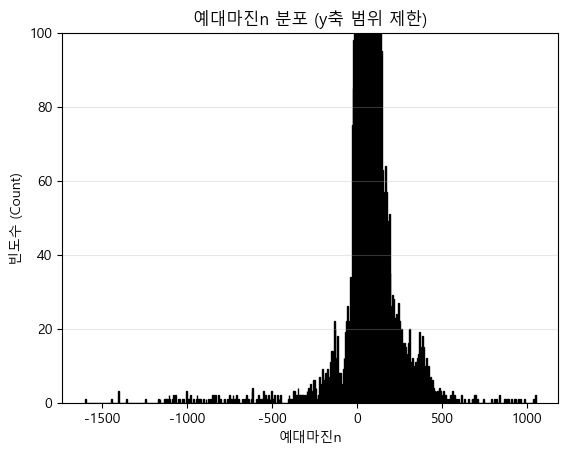

In [155]:
# 1. 히스토그램 그리기 (x축 범위는 range로 설정)
plt.hist(df3['예대마진n'], bins=500, color='skyblue', edgecolor='black')

# 2. y축 범위 설정 (예: 빈도수가 0부터 100까지만 보이게 제한)
# 이렇게 하면 너무 높게 솟은 막대기는 잘리고, 낮은 막대기들이 자세히 보입니다.
plt.ylim(0, 100) 

plt.title('예대마진n 분포 (y축 범위 제한)')
plt.xlabel('예대마진n')
plt.ylabel('빈도수 (Count)')
plt.grid(axis='y', alpha=0.3)
plt.show()

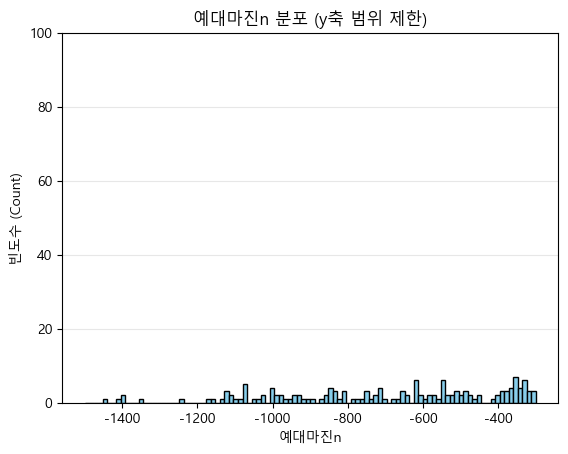

In [244]:
# 1. 히스토그램 그리기 (x축 범위는 range로 설정)
plt.hist(df3['예대마진n'], bins=100, color='skyblue', edgecolor='black',range=(-1500,-300))

# 2. y축 범위 설정 (예: 빈도수가 0부터 100까지만 보이게 제한)
# 이렇게 하면 너무 높게 솟은 막대기는 잘리고, 낮은 막대기들이 자세히 보입니다.
plt.ylim(0, 100) 

plt.title('예대마진n 분포 (y축 범위 제한)')
plt.xlabel('예대마진n')
plt.ylabel('빈도수 (Count)')
plt.grid(axis='y', alpha=0.3)
plt.show()
# ~-100까지 끊고

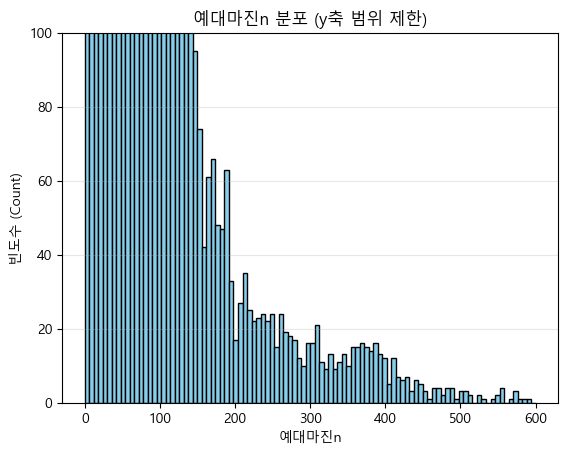

In [180]:
# 1. 히스토그램 그리기 (x축 범위는 range로 설정)
plt.hist(df3['예대마진n'], bins=100, color='skyblue', edgecolor='black',range=(0,600))

# 2. y축 범위 설정 (예: 빈도수가 0부터 100까지만 보이게 제한)
# 이렇게 하면 너무 높게 솟은 막대기는 잘리고, 낮은 막대기들이 자세히 보입니다.
plt.ylim(0, 100) 

plt.title('예대마진n 분포 (y축 범위 제한)')
plt.xlabel('예대마진n')
plt.ylabel('빈도수 (Count)')
plt.grid(axis='y', alpha=0.3)
plt.show()
# 500~ 이렇게 끊어서 보면 될 듯.

In [245]:
b= df3[df3['예대마진n'] > 300]

In [247]:
b['법인_고객등급'].value_counts()

법인_고객등급
최우수    356
일반       4
Name: count, dtype: int64

In [ ]:
zz= df3[df3['예대마진n']<-100]
# zz= 106개(x < -500) == 2.94, zz=416개 (x < -100) == 11.5

In [205]:
aa= df3[df3['사업장_시도']=='미상']

In [199]:
aa.describe()

,기준년월,요구불예금잔액,거치식예금잔액,적립식예금잔액,수익증권잔액,신탁잔액,퇴직연금잔액,여신한도금액,여신_운전자금대출잔액,여신_시설자금대출잔액,외환_수출실적금액,외환_수입실적금액,신용카드사용금액,체크카드사용금액,창구거래금액,인터넷뱅킹거래금액,스마트뱅킹거래금액,폰뱅킹거래금액,ATM거래금액,자동이체금액,요구불입금금액,요구불출금금액,요구불예금좌수,거치식예금좌수,적립식예금좌수,수익증권좌수,신탁좌수,퇴직연금좌수,여신_운전자금대출좌수,여신_시설자금대출좌수,신용카드개수,외환_수출실적거래건수,외환_수입실적거래건수,창구거래건수,인터넷뱅킹거래건수,스마트뱅킹거래건수,폰뱅킹거래건수,ATM거래건수,자동이체거래건수,총예금잔액,자산관리잔액,총대출잔액,총예금좌수,총대출좌수,자산관리좌수,총요구불입출금,전체거래액,총디지털거래액,총오프라인거래액,총카드소비,총외환실적,예대마진,평균대출금리(%),평균예금금리(%),예대마진(%),예금이자,대출이자,예대마진n,예대마진수익률n(%)
count,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000,16993.000000
mean,202297.293415,67.034462,20.521815,4.693624,0.326864,46.584418,33.473378,247.043842,364.165582,220.571347,0.004472,0.001845,3.395835,0.049281,28.928508,177.183352,10.457976,2.649845,28.853493,38.575837,234.427242,237.476883,3.560790,0.157535,0.157506,0.033720,0.278585,0.225505,4.924587,0.340493,3.811481,0.090949,0.031484,2.254046,20.999735,2.476343,0.776025,1.949538,16.356912,92.249901,80.384660,584.736929,3.875831,5.265080,0.537810,471.904125,248.073174,190.291173,57.782001,3.445117,0.006317,26.035775,0.424116,0.271204,0.153447,0.251267,2.480447,2.229180,0.261751
std,81.321476,227.092755,181.338507,40.453142,11.850673,221.598650,163.742989,1968.181422,800.411318,1153.694983,0.046497,0.022078,8.087516,0.596157,182.620139,544.326080,111.112253,19.271842,458.510158,142.401512,726.407110,731.838548,3.164154,1.001669,0.836652,0.208923,0.556547,0.443744,9.569479,0.976565,4.851007,0.865777,0.345442,7.820127,22.607950,7.388422,4.183125,5.636854,14.385030,326.926096,364.536101,1494.245083,3.519744,9.877283,1.012398,1449.973975,940.490134,569.651217,510.519148,8.140037,0.058024,75.312402,0.054513,0.057896,0.016902,0.901310,6.385334,6.424614,0.249162
min,202201.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-191.720000,0.290000,0.150000,0.110000,0.000000,0.000000,-16.011200,-0.350000
25%,202208.000000,0.170000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.600000,4.300000,5.800000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.500000,0.220000,0.000000,30.000000,2.000000,1.000000,0.000000,12.000000,1.900000,0.280000,0.000000,0.000000,0.000000,0.686814,0.410000,0.230000,0.140000,0.000594,0.122400,0.060265,0.182353
50%,202305.000000,3.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,99.000000,0.000000,0.000000,0.000000,0.820000,0.000000,0.000000,28.000000,0.000000,0.000000,0.000000,6.500000,50.000000,56.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,2.000000,0.000000,0.000000,0.000000,7.500000,0.000000,0.000000,0.000000,15.000000,5.200000,0.000000,130.000000,4.000000,2.000000,0.000000,111.000000,52.000000,37.000000,0.000000,0.820000,0.000000,4.998612,0.440000,0.

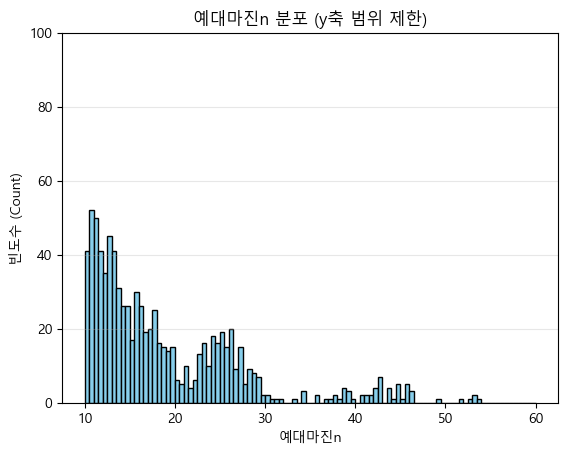

In [219]:
# 1. 히스토그램 그리기 (x축 범위는 range로 설정)
plt.hist(aa['예대마진n'], bins=100, color='skyblue', edgecolor='black', range=(10,60))

# 2. y축 범위 설정 (예: 빈도수가 0부터 100까지만 보이게 제한)
# 이렇게 하면 너무 높게 솟은 막대기는 잘리고, 낮은 막대기들이 자세히 보입니다.
plt.ylim(0, 100) 

plt.title('예대마진n 분포 (y축 범위 제한)')
plt.xlabel('예대마진n')
plt.ylabel('빈도수 (Count)')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [227]:
aaa= aa[aa['예대마진n']>60]
# 35개

In [230]:
aa['업종_중분류'].value_counts()

업종_중분류
도매 및 상품 중개업                     3095
전문직별 공사업                        1562
섬유제품 제조업; 의복제외                  1005
부동산업                             991
종합 건설업                           885
소매업; 자동차 제외                      881
자동차 및 트레일러 제조업                   810
금속가공제품 제조업; 기계 및 가구 제외           698
기타 기계 및 장비 제조업                   690
육상운송 및 파이프라인 운송업                 567
1차 금속 제조업                        513
화학물질 및 화학제품 제조업; 의약품 제외          489
교육 서비스업                          381
건축기술, 엔지니어링 및 기타 과학기술 서비스업       377
사업지원 서비스업                        354
식료품 제조업                          354
창고 및 운송관련 서비스업                   334
전기장비 제조업                         249
기타 개인 서비스업                       185
자동차 및 부품 판매업                     169
협회 및 단체                          166
고무 및 플라스틱제품 제조업                  157
비금속 광물제품 제조업                     143
펄프, 종이 및 종이제품 제조업                140
의복, 의복 액세서리 및 모피제품 제조업           128
전문 서비스업                          125
기타 제품 제조업                      

In [228]:
aaa['업종_중분류'].value_counts()
# >50 으로하면 자동차 및 트레일러 제조업이 +5, >60으로하면 only 수상운송업

업종_중분류
수상 운송업    35
Name: count, dtype: int64

In [231]:
aaaa= aa[aa['업종_중분류']== '수상 운송업']

In [232]:
aaaa.shape

(53, 66)

In [237]:
aaaa['예대마진수익률n(%)'].value_counts().sort_index()

예대마진수익률n(%)
-0.350000    2
-0.330000    1
-0.310000    1
-0.290000    1
-0.280000    1
-0.280000    2
-0.230000    1
-0.230000    1
-0.200000    1
-0.170000    1
-0.160000    1
-0.150000    2
 0.289973    1
 0.299988    1
 0.312424    1
 0.322329    1
 0.329971    1
 0.339992    1
 0.359992    1
 0.369982    1
 0.369983    1
 0.409980    1
 0.409985    1
 0.414953    1
 0.419977    1
 0.419979    1
 0.419985    1
 0.419994    1
 0.419998    1
 0.429984    1
 0.439980    1
 0.439988    1
 0.449979    1
 0.449985    1
 0.449999    1
 0.459969    1
 0.459973    1
 0.459984    1
 0.459989    1
 0.459991    1
 0.464340    1
 0.469946    1
 0.469969    1
 0.469986    1
 0.469992    1
 0.479585    1
 0.479975    1
 0.479977    1
 0.479990    1
 0.499980    1
Name: count, dtype: int64

In [240]:
aaaa['기준년월'].value_counts().sort_index()

기준년월
202201    2
202202    2
202203    2
202204    2
202205    2
202206    2
202207    2
202208    2
202209    2
202210    2
202211    2
202212    2
202301    2
202302    2
202303    2
202304    2
202305    2
202306    2
202307    1
202308    1
202309    1
202310    1
202311    1
202312    1
202401    1
202402    1
202403    1
202404    1
202405    1
202406    1
202407    1
202408    1
202409    1
202410    1
202411    1
Name: count, dtype: int64

In [243]:
aaaa['법인_고객등급'].value_counts()

법인_고객등급
최우수    52
우수      1
Name: count, dtype: int64

In [193]:
zz.info()

<class 'pandas.core.frame.DataFrame'>
Index: 416 entries, 1013 to 341671
Data columns (total 66 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   기준년월         416 non-null    int64  
 1   업종_대분류       416 non-null    object 
 2   업종_중분류       416 non-null    object 
 3   사업장_시도       416 non-null    object 
 4   사업장_시군구      416 non-null    object 
 5   법인_고객등급      416 non-null    object 
 6   전담고객여부       416 non-null    object 
 7   요구불예금잔액      416 non-null    float64
 8   거치식예금잔액      416 non-null    float64
 9   적립식예금잔액      416 non-null    float64
 10  수익증권잔액       416 non-null    float64
 11  신탁잔액         416 non-null    float64
 12  퇴직연금잔액       416 non-null    float64
 13  여신한도금액       416 non-null    float64
 14  여신_운전자금대출잔액  416 non-null    float64
 15  여신_시설자금대출잔액  416 non-null    float64
 16  외환_수출실적금액    416 non-null    float64
 17  외환_수입실적금액    416 non-null    float64
 18  신용카드사용금액     416 non-null    float64
 19  체크카드사용금

In [197]:
zz['기준년월'].value_counts().sort_index()

기준년월
202201     9
202202     9
202203    11
202204     9
202205    10
202206    11
202207    11
202208    10
202209    10
202210    10
202211    11
202212    10
202301    10
202302    11
202303    11
202304    13
202305    12
202306    11
202307    11
202308    10
202309    12
202310    11
202311    13
202312    13
202401    15
202402    14
202403    13
202404    11
202405    11
202406    14
202407    12
202408    16
202409    16
202410    15
202411    12
202412     8
Name: count, dtype: int64

In [ ]:
# count = 106, 업종대분류 = 금융 및 보험업 :: 서울70, 부산- 동구36
zz['사업장_시도'].value_counts()

사업장_시도
서울특별시    280
대구광역시     97
부산광역시     36
경상북도       3
Name: count, dtype: int64

In [195]:
zz['사업장_시군구'].value_counts()

사업장_시군구
중구        163
영등포구       95
강남구        74
동구         36
달서구        28
서초구        13
포항시 북구      3
강서구         3
종로구         1
Name: count, dtype: int64

In [196]:
z_busan = zz[zz['사업장_시도']=='부산광역시']

In [169]:
z_busan

,기준년월,업종_대분류,업종_중분류,사업장_시도,사업장_시군구,법인_고객등급,전담고객여부,요구불예금잔액,거치식예금잔액,적립식예금잔액,수익증권잔액,신탁잔액,퇴직연금잔액,여신한도금액,여신_운전자금대출잔액,여신_시설자금대출잔액,외환_수출실적금액,외환_수입실적금액,신용카드사용금액,체크카드사용금액,창구거래금액,인터넷뱅킹거래금액,스마트뱅킹거래금액,폰뱅킹거래금액,ATM거래금액,자동이체금액,요구불입금금액,요구불출금금액,요구불예금좌수,거치식예금좌수,적립식예금좌수,수익증권좌수,신탁좌수,퇴직연금좌수,여신_운전자금대출좌수,여신_시설자금대출좌수,신용카드개수,외환_수출실적거래건수,외환_수입실적거래건수,창구거래건수,인터넷뱅킹거래건수,스마트뱅킹거래건수,폰뱅킹거래건수,ATM거래건수,자동이체거래건수,총예금잔액,자산관리잔액,총대출잔액,총예금좌수,총대출좌수,자산관리좌수,총요구불입출금,전체거래액,총디지털거래액,총오프라인거래액,총카드소비,총외환실적,예대마진,고객유형,평균대출금리(%),평균예금금리(%),예대마진(%),예금이자,대출이자,예대마진n,예대마진수익률n(%)
319407,202201,금융 및 보험업,금융업,부산광역시,동구,최우수,N,0.0,362000.0,0.0,0.0,59000.0,59000.0,5000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,61000.0,9200.0,0.0,2.0,55.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55.0,362000.0,118000.0,0.0,57.0,0.0,2.0,9200.0,0.0,0.0,0.0,0.0,0.0,-12561.4,비용 유발형,0.29,0.15,0.15,543.0,0.0,-543.0,-0.150000
328846,202202,금융 및 보험업,금융업,부산광역시,동구,최우수,N,0.0,359000.0,0.0,0.0,59000.0,59000.0,5000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31000.0,4700.0,0.0,2.0,55.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55.0,359000.0,118000.0,0.0,57.0,0.0,2.0,4700.0,0.0,0.0,0.0,0.0,0.0,-12457.3,비용 유발형,0.30,0.15,0.15,538.5,0.0,-538.5,-0.150000
338299,202203,금융 및 보험업,금융업,부산광역시,동구,최우수,N,0.0,356000.0,0.0,0.0,59000.0,59000.0,5000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36000.0,11000.0,0.0,2.0,55.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55.0,356000.0,118000.0,0.0,57.0,0.0,2.0,11000.0,0.0,0.0,0.0,0.0,0.0,-12353.2,비용 유발형,0.33,0.16,0.17,569.6,0.0,-569.6,-0.160000
290858,202204,금융 및 보험업,금융업,부산광역시,동구,최우수,N,0.0,348000.0,0.0,0.0,59000.0,59000.0,5000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,46000.0,4300.0,0.0,2.0,55.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55.0,348000.0,118000.0,0.0,57.0,0.0,2.0,4300.0,0.0,0.0,0.0,0.0,0.0,-12075.6,비용 유발형,0.34,0.17,0.17,591.6,0.0,-591.6,-0.170000
300338,202205,금융 및 보험업,금융업,부산광역시,동구,최우수,N,0.0,337000.0,0.0,0.0,59000.0,59000.0,5000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,46000.0,4100.0,0.0,2.0,55.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55.0,337000.0,118000.0,0.0,57.0,0.0,2.0,4100.0,0.0,0.0,0.0,0.0,0.0,-11693.9,비용 유발형,0.36,0.19,0.17,640.3,0.0,-640.3,-0.190000
309921,202206,금융 및 보험업,금융업,부산광역시,동구,최우수,N,0.0,326000.0,0.0,0.0,59000.0,59000.0,5000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,48000.0,4200.0,0.0,2.0,55.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55.0,326000.0,118000.0,0.0,57.0,0.0,2.0,4200.0,0.0,0.0,0.0,0.0,0.0,-11312.2,비용 유발형,0.37,0.20,0.17,652.0,0.0,-652.0,-0.200000
261785,202207,금융 및 보험업,금융업,부산광역시,동구,최우수,N,0.0,321000.0,0.0,0.0,59000.0,59000.0,5000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,43000.0,4700.0,0.0,2.0,55.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55.0,321000.0,118000.0,0.0,57.0,0.0,2.0,4700.0,0.0,0.0,0.0,0.0,0.0,-11138.7,비용 유발형,0.37,0.23,0.14,738.3,0.0,-738.3,-0.230000
271492,202208,금융 및 보험업,금융업,부산광역시,동구,최우수,N,0.0,317000.0,0.0,0.0,59000.0,59000.0,5000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28000.0,3800.0,0.0,2.0,55.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55.0,317000.0,118000.0,0.0,57.0,0.0,2.0,3800.0,0.0,0.0,0.0,0.0,0.0,-10999.9,비용 유발형,0.41,0.23,0.17,729.1,0.0,-729.1,-0.230000
281263,202209,금융 및 보험업,금융업,부산광역시,동구,최우수,N,0.0,312000.0,0.0,0.0,59000.0,59000.0,5000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24000.0,3600.0,0.0,2.0,55.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55.0,312000.0,118000.0,0.0,57.0,0.0,2.0,3600.0,0.0,0.0,0.0,0.0,0.0,-10826.4,비용 유발형,0.42,0.29,0.13,904.8,0.0,-904.8,-0.290000
232545,202210,금융 및 보험업,금융업,부산광역시,동구,최우수,N,0.0,307000.0,0.0,0.0,59000.0,59000.0,5000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25000.0,3300.0,0.0,2.0,55.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55.0,307000.0,118000.0,0.0,57.0,0.0,2.0,3300.0,0.0,0.0,0.0,0.0,0.0,-10652.9,비용 유발형,0.46,0.35,0.11,1074.5,0.0,-1074.5,-0.350000


In [171]:
df2.describe().round(2)

,기준년월,요구불예금잔액,거치식예금잔액,적립식예금잔액,수익증권잔액,신탁잔액,퇴직연금잔액,여신한도금액,여신_운전자금대출잔액,여신_시설자금대출잔액,외환_수출실적금액,외환_수입실적금액,신용카드사용금액,체크카드사용금액,창구거래금액,인터넷뱅킹거래금액,스마트뱅킹거래금액,폰뱅킹거래금액,ATM거래금액,자동이체금액,요구불입금금액,요구불출금금액,요구불예금좌수,거치식예금좌수,적립식예금좌수,수익증권좌수,신탁좌수,퇴직연금좌수,여신_운전자금대출좌수,여신_시설자금대출좌수,신용카드개수,외환_수출실적거래건수,외환_수입실적거래건수,창구거래건수,인터넷뱅킹거래건수,스마트뱅킹거래건수,폰뱅킹거래건수,ATM거래건수,자동이체거래건수,총예금잔액,자산관리잔액,총대출잔액,총예금좌수,총대출좌수,자산관리좌수,총요구불입출금,전체거래액,총디지털거래액,총오프라인거래액,총카드소비,총외환실적,예대마진,평균대출금리(%),평균예금금리(%),예대마진(%),예금이자,대출이자,예대마진n,예대마진수익률n(%)
count,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00,347299.00
mean,202306.94,162.04,610.57,3.89,0.84,233.10,79.61,646.39,823.20,806.52,0.02,0.02,5.97,0.16,254.44,804.16,13.46,2.99,110.41,195.27,906.86,1156.40,3.75,0.21,0.13,0.04,0.31,0.24,4.89,0.68,4.31,0.13,0.12,1.74,20.83,2.87,0.56,1.92,17.12,776.50,313.55,1629.72,4.09,5.57,0.59,2063.26,1185.46,820.61,364.85,6.13,0.03,54.54,0.43,0.27,0.15,2.15,6.98,4.83,0.30
std,81.71,2441.79,40304.21,40.73,22.67,5569.77,888.43,4853.18,3886.92,3810.15,0.41,0.39,113.28,2.59,18745.79,25270.54,135.00,38.76,2024.74,4089.33,22108.44,29334.98,4.59,1.84,0.77,0.36,0.84,0.48,9.42,1.41,5.96,1.58,1.01,6.42,22.62,8.59,3.68,6.13,14.96,40416.68,5795.17,5654.21,5.27,9.66,1.29,48511.33,34957.43,25275.01,18920.43,113.39,0.59,1352.35,0.05,0.05,0.02,117.80,24.54,113.65,0.22
min,202201.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-202001.65,0.29,0.15,0.11,0.00,0.00,-19204.15,-0.35
25%,202210.00,0.34,0.00,0.00,0.00,0.00,0.00,0.00,17.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.40,5.70,7.80,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.50,0.40,0.00,64.00,1.00,1.00,0.00,15.80,1.00,0.00,0.00,0.00,0.00,2.15,0.41,0.27,0.14,0.00,0.27,0.19,0.28
50%,202307.00,6.60,0.00,0.00,0.00,0.00,0.00,0.00,150.00,0.00,0.00,0.00,1.00,0.00,0.00,28.00,0.00,0.00,0.00,9.50,56.00,62.00,2.00,0.00,0.00,0.00,0.00,0.00,2.00,0.00,2.00,0.00,0.00,0.00,7.50,0.00,0.00,0.00,15.00,8.10,0.00,320.00,2.00,2.00,0.00,125.00,52.90,39.00,0.00,1.10,0.00,14.49,0.44,0.29,0.15,0.02,1.39,1.23,0.40
75%,202404.00,55.00,0.00,0.00,0.00,0.00,0.00,200.00,520.00,350.00,0.00,0.00,4.60,0.00,0.11,180.00,0.63,0.00,0.30,30.00,250.00,260.00,4.00,0.00,0.00,0.00,0.00,0.00,4.00,1.00,4.00,0.00,0.00,1.00,45.00,1.00,0.00,1.00,25.00,68.00,0.00,1230.00,4.00,5.00,1.00,520.00,250.36,200.00,5.00,4.70,0.00,58.34,0.47,0.30,0.17,0.18,5.28,4.92,0.44
max,202412.00,304000.00,6026000.00,3400.00,3400.00,675000.00,62000.00,300000.00,245000.00,273000.00,65.00,81.00,26000.00,790.00,7619000.00,2162000.00,24000.00,6800.00,259000.00,292000.00,5172000.00,5192000.00,55.00,55.00,35.50,15.50,45.50,4.00,55.00,25.50,55.00,55.00,55.00,55.00,55.00,55.00,55.00,55.00,55.00,6026000.00,675000.00,273000.00,114.00,70.50,45.50,10364000.00,9010000.00,2162000.00,7619000.00,26000.00,81.00,11735.40,0.50,0.35,0.19,19885.80,1146.60,1049.01,0.50


In [166]:
z= zz.sort_values(by='기준년월', ascending=True)
z.head(30)

,기준년월,업종_대분류,업종_중분류,사업장_시도,사업장_시군구,법인_고객등급,전담고객여부,요구불예금잔액,거치식예금잔액,적립식예금잔액,수익증권잔액,신탁잔액,퇴직연금잔액,여신한도금액,여신_운전자금대출잔액,여신_시설자금대출잔액,외환_수출실적금액,외환_수입실적금액,신용카드사용금액,체크카드사용금액,창구거래금액,인터넷뱅킹거래금액,스마트뱅킹거래금액,폰뱅킹거래금액,ATM거래금액,자동이체금액,요구불입금금액,요구불출금금액,요구불예금좌수,거치식예금좌수,적립식예금좌수,수익증권좌수,신탁좌수,퇴직연금좌수,여신_운전자금대출좌수,여신_시설자금대출좌수,신용카드개수,외환_수출실적거래건수,외환_수입실적거래건수,창구거래건수,인터넷뱅킹거래건수,스마트뱅킹거래건수,폰뱅킹거래건수,ATM거래건수,자동이체거래건수,총예금잔액,자산관리잔액,총대출잔액,총예금좌수,총대출좌수,자산관리좌수,총요구불입출금,전체거래액,총디지털거래액,총오프라인거래액,총카드소비,총외환실적,예대마진,고객유형,평균대출금리(%),평균예금금리(%),예대마진(%),예금이자,대출이자,예대마진n,예대마진수익률n(%)
320999,202201,금융 및 보험업,금융업,서울특별시,영등포구,최우수,Y,54.0,844000.0,0.0,0.0,0.0,0.0,0.0,0.0,84000.0,0.0,0.0,0.0,0.0,50000.0,0.0,0.0,0.0,0.0,18000.0,2200.0,0.0,8.0,55.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,55.0,844054.0,0.0,84000.0,63.0,8.0,0.0,2200.0,50000.0,0.0,50000.0,0.0,0.0,-25088.6738,비용 유발형,0.29,0.15,0.15,1266.0810,243.6,-1022.4810,-0.110175
319407,202201,금융 및 보험업,금융업,부산광역시,동구,최우수,N,0.0,362000.0,0.0,0.0,59000.0,59000.0,5000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,61000.0,9200.0,0.0,2.0,55.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55.0,362000.0,118000.0,0.0,57.0,0.0,2.0,9200.0,0.0,0.0,0.0,0.0,0.0,-12561.4000,비용 유발형,0.29,0.15,0.15,543.0000,0.0,-543.0000,-0.150000
330440,202202,금융 및 보험업,금융업,서울특별시,영등포구,최우수,Y,54.0,601000.0,0.0,0.0,0.0,0.0,0.0,0.0,64000.0,0.0,0.0,0.0,0.0,60000.0,0.0,0.0,0.0,0.0,35000.0,1500.0,0.0,8.0,55.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,55.0,601054.0,0.0,64000.0,63.0,8.0,0.0,1500.0,60000.0,0.0,60000.0,0.0,0.0,-17656.5738,비용 유발형,0.30,0.15,0.15,901.5810,192.0,-709.5810,-0.106695
328846,202202,금융 및 보험업,금융업,부산광역시,동구,최우수,N,0.0,359000.0,0.0,0.0,59000.0,59000.0,5000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31000.0,4700.0,0.0,2.0,55.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55.0,359000.0,118000.0,0.0,57.0,0.0,2.0,4700.0,0.0,0.0,0.0,0.0,0.0,-12457.3000,비용 유발형,0.30,0.15,0.15,538.5000,0.0,-538.5000,-0.150000
339880,202203,금융 및 보험업,금융업,서울특별시,영등포구,최우수,Y,54.0,447000.0,0.0,0.0,0.0,0.0,0.0,0.0,64000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29000.0,1200.0,0.0,8.0,55.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55.0,447054.0,0.0,64000.0,63.0,8.0,0.0,1200.0,0.0,0.0,0.0,0.0,0.0,-12312.7738,비용 유발형,0.33,0.16,0.17,715.2864,211.2,-504.0864,-0.098637
338299,202203,금융 및 보험업,금융업,부산광역시,동구,최우수,N,0.0,356000.0,0.0,0.0,59000.0,59000.0,5000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36000.0,11000.0,0.0,2.0,55.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55.0,356000.0,118000.0,0.0,57.0,0.0,2.0,11000.0,0.0,0.0,0.0,0.0,0.0,-12353.2000,비용 유발형,0.33,0.16,0.17,569.6000,0.0,-569.6000,-0.160000
290858,202204,금융 및 보험업,금융업,부산광역시,동구,최우수,N,0.0,348000.0,0.0,0.0,59000.0,59000.0,5000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,46000.0,4300.0,0.0,2.0,55.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55.0,348000.0,118000.0,0.0,57.0,0.0,2.0,4300.0,0.0,0.0,0.0,0.0,0.0,-12075.6000,비용 유발형,0.34,0.17,0.17,591.6000,0.0,-591.6000,-0.170000
300338,202205,금융 및 보험업,금융업,부산광역시,동구,최우수,N,0.0,337000.0,0.0,0.0,59000.0,59000.0,5000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,46000.0,4100.0,0.0,2.0,55.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55.0,337000.0,118000.0,0.0,57.0,0.0,2.0,4100.0,0.0,0.0,0.0,0.0,0.0,-11693.9000,비용 유발형,0.36,0.19,0.17,640.3000,0.0,-640.3000,-0.190000
309921,202206,금융 및 보험업,금융업,부산광역시,동구,최우수,N,0.0,326000.0,0.0,0.0,59000.0,59000.0,5000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,48000.0,4200.0,0.0,2.0,55.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55.0,326000.0,118000.0,0.0,57.0,0.0,2.0,4200.0,0.0,0.0,0.0,0.0,0.0,-11312.2000,비용 유발형,0.37,0.20,0.17,652.0000,0.0,-652.0000,-0.200000
261785,202207,금융 및 보험업,금융업,부산광역시,동구,최우수,N,0.0,321000.0,0.0,0.0,59000.0,59000.0,5000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,43000.0,4700.0,0.0,2.0,55.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55.0,321000.0,118000.0,0.0,57.0,0.0,2.0,4700.0,0.0,0.0,0.0,0.0,0.0,-11138.7000,비용 유발형,0.37,0.23,0.14,738.3000,